# Welcome to The Vault
This is where I retire all once-promising figures and code that didn't make the final cut, but may one day see the light of day again. Watch your step, it's dark down here. Who knows what one might find in The Vault.

# Setup

In [11]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import os
import logging

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from foraging import plotting
from foraging import utils
from matplotlib.lines import Line2D
from matplotlib.colors import LogNorm
from sklearn.model_selection import train_test_split

from foraging.config.constants import BOX_LABELS, BOX_COLORS
from foraging.plotting import beliefs as plot_beliefs
from foraging.utils import INDEX
from foraging.plotting import bp, format_yticks, per_block, titler, enhanced_violinplot
from foraging.plotting.behavior import (
    plot_continuous3d_df,
    plot_continuous2d_df,
    plot_frequencies_over_experiment,
)
from foraging.utils.data import get_continuous_from_df_to_dict, filter_df, get_blocks

# Filter out annoying matplotlib logs
mlogger = logging.getLogger("matplotlib")
mlogger.setLevel(logging.WARNING)

# constants
SEED = 42
RNG = np.random.default_rng(SEED)
DATA_DIR = "../data"
FIGURES_DIR = "../figures"
# Filter out annoying matplotlib logs
mlogger = logging.getLogger("matplotlib")
mlogger.setLevel(logging.WARNING)

# constants
SEED = 42
RNG = np.random.default_rng(SEED)
DATA_DIR = "../data"
FIGURES_DIR = "../figures"
EXPERIMENT_DIR = "../data/experiments"
ANALYSIS_DIR = "../data/analysis"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Load Data

In [4]:
df = utils.data.make_df(os.path.join(DATA_DIR, "experiments"))
df = utils.data.exclusion_criteria(df)
utils.data.display_df(df, ["box", "push times", "reward outcomes"])

|                                                       | box    |   push times | reward outcomes   |
|:------------------------------------------------------|:-------|-------------:|:------------------|
| ('dylan', 20211206, 2, 1, 'probability', 1, 0.1, 'M') | slow   |        3.135 | False             |
| ('dylan', 20211206, 2, 2, 'probability', 1, 0.1, 'M') | fast   |        8.465 | False             |
| ('dylan', 20211206, 2, 3, 'probability', 1, 0.1, 'M') | fast   |        9.468 | False             |
| ('dylan', 20211206, 2, 4, 'probability', 1, 0.1, 'M') | fast   |       11.667 | False             |
| ('dylan', 20211206, 2, 5, 'probability', 1, 0.1, 'M') | medium |       17.125 | False             |

# Push Interval Violinplots

array([[<Axes: title={'center': 'kappa=0.01'}, ylabel='dylan'>,
        <Axes: title={'center': 'kappa=0.04'}>,
        <Axes: title={'center': 'kappa=0.07'}>,
        <Axes: title={'center': 'kappa=0.1'}>, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: title={'center': 'kappa=-1.0'}, ylabel='humans'>,
        <Axes: title={'center': 'kappa=0.0'}>,
        <Axes: title={'center': 'kappa=0.02'}>,
        <Axes: title={'center': 'kappa=0.03'}>,
        <Axes: title={'center': 'kappa=0.04'}>,
        <Axes: title={'center': 'kappa=0.06'}>,
        <Axes: title={'center': 'kappa=0.07'}>,
        <Axes: title={'center': 'kappa=0.08'}>,
        <Axes: title={'center': 'kappa=0.1'}>, <Axes: >],
       [<Axes: title={'center': 'kappa=0.01'}, ylabel='marco'>,
        <Axes: title={'center': 'kappa=0.1'}>,
        <Axes: title={'center': 'kappa=0.2'}>, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: title={'center

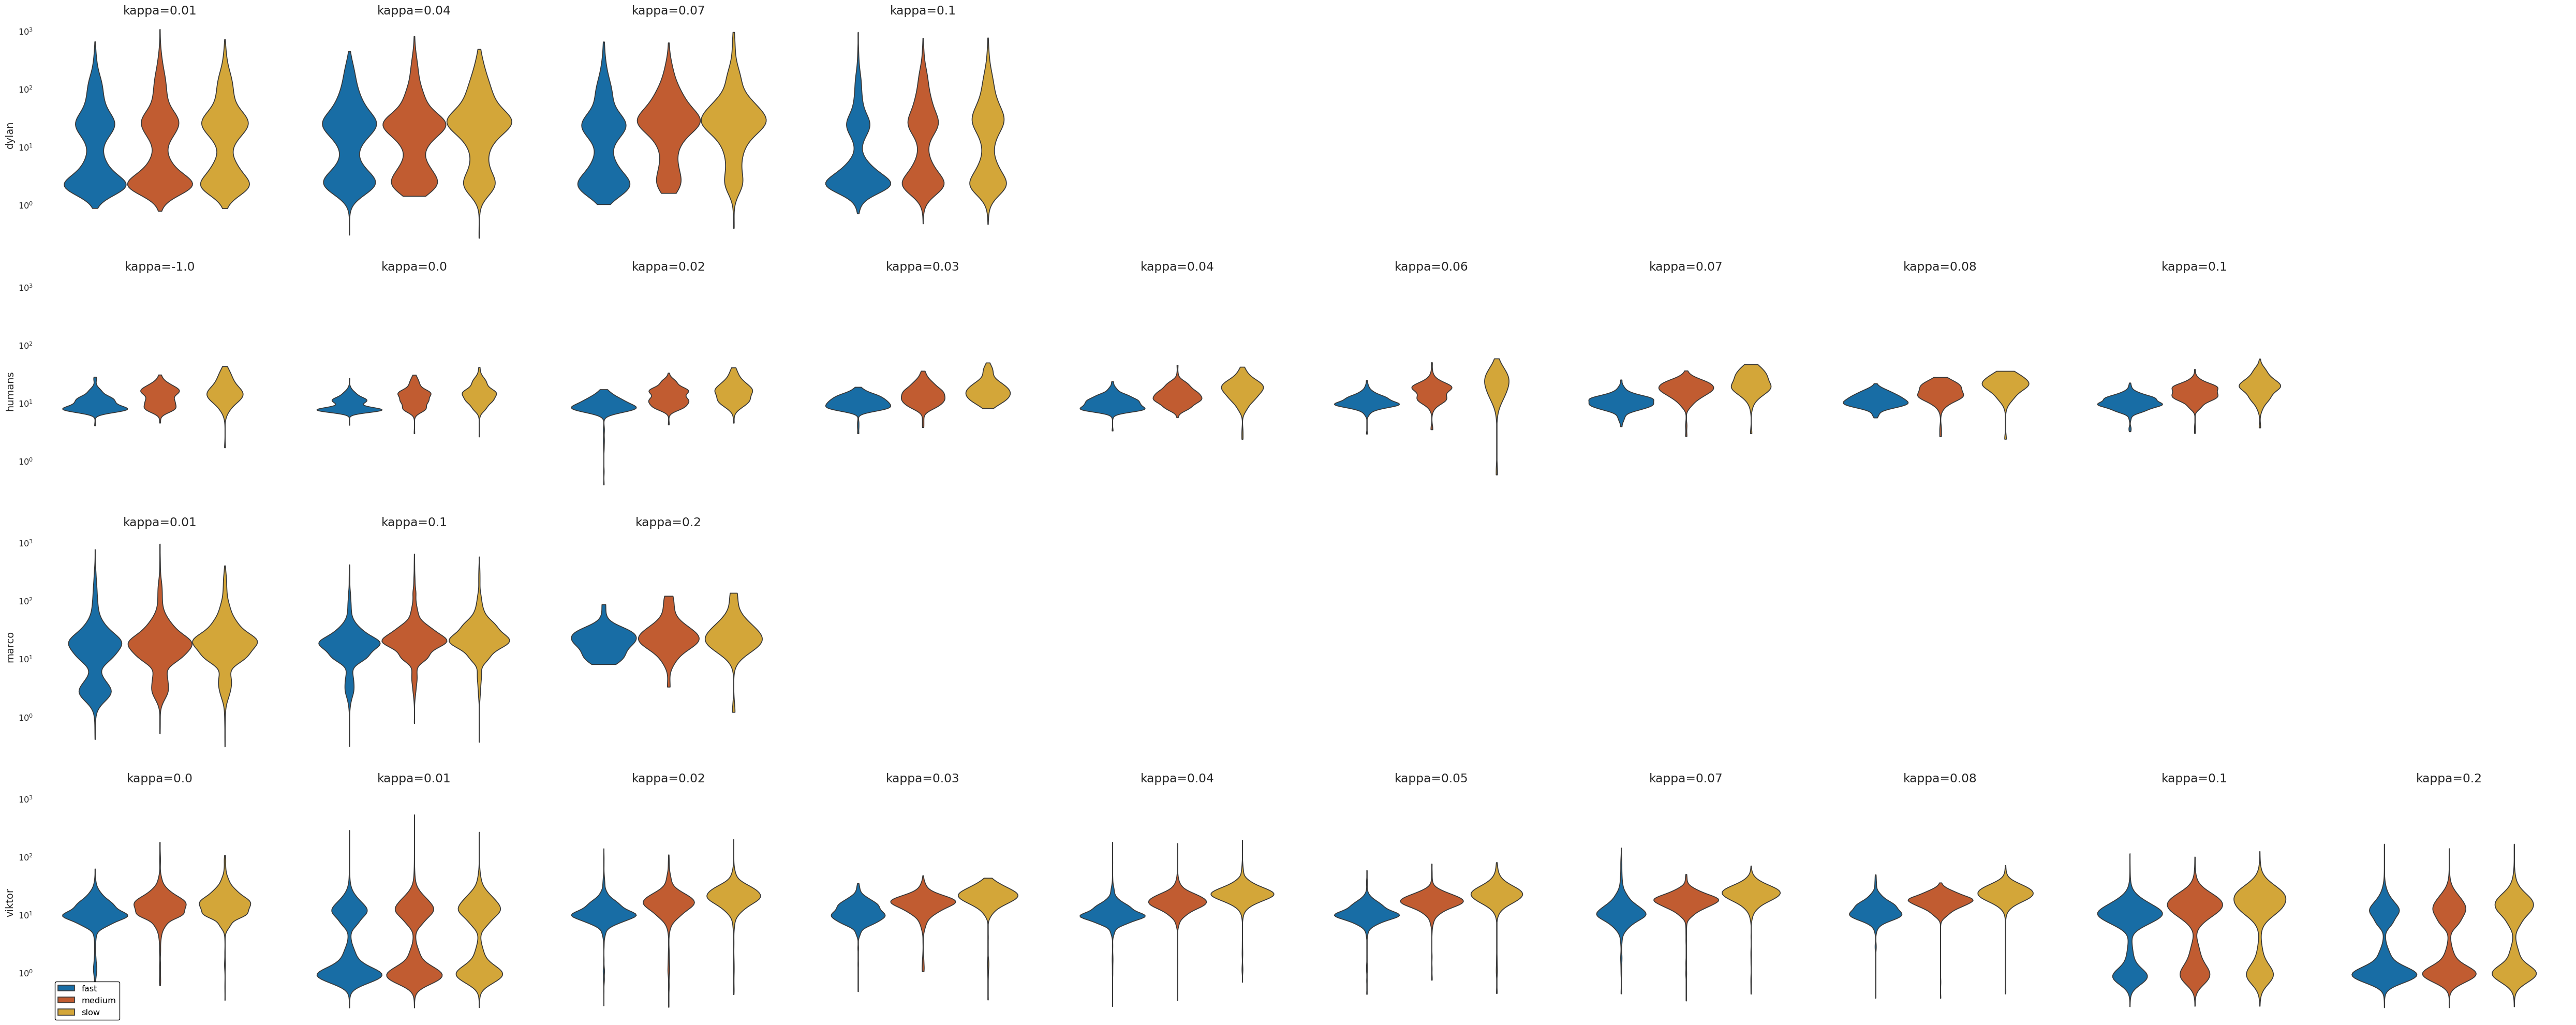

In [4]:
plotting.plot_variable_subplots(
    df,
    bp(sns.violinplot),
    "subject",
    "kappa",
    fig_kwargs={"sharey": True},
    y="same-box push intervals",
    accumulate=True,
    cut=0,
    inner=None,
    common_norm=True,
    log_scale=True,
    legend=True,
)

# Normalized Push Interval Violinplots

array([[<Axes: title={'center': 'kappa=0.01'}, ylabel='dylan'>,
        <Axes: title={'center': 'kappa=0.04'}>,
        <Axes: title={'center': 'kappa=0.07'}>,
        <Axes: title={'center': 'kappa=0.1'}>, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: title={'center': 'kappa=-1.0'}, ylabel='humans'>,
        <Axes: title={'center': 'kappa=0.0'}>,
        <Axes: title={'center': 'kappa=0.02'}>,
        <Axes: title={'center': 'kappa=0.03'}>,
        <Axes: title={'center': 'kappa=0.04'}>,
        <Axes: title={'center': 'kappa=0.06'}>,
        <Axes: title={'center': 'kappa=0.07'}>,
        <Axes: title={'center': 'kappa=0.08'}>,
        <Axes: title={'center': 'kappa=0.1'}>, <Axes: >],
       [<Axes: title={'center': 'kappa=0.01'}, ylabel='marco'>,
        <Axes: title={'center': 'kappa=0.1'}>,
        <Axes: title={'center': 'kappa=0.2'}>, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: title={'center

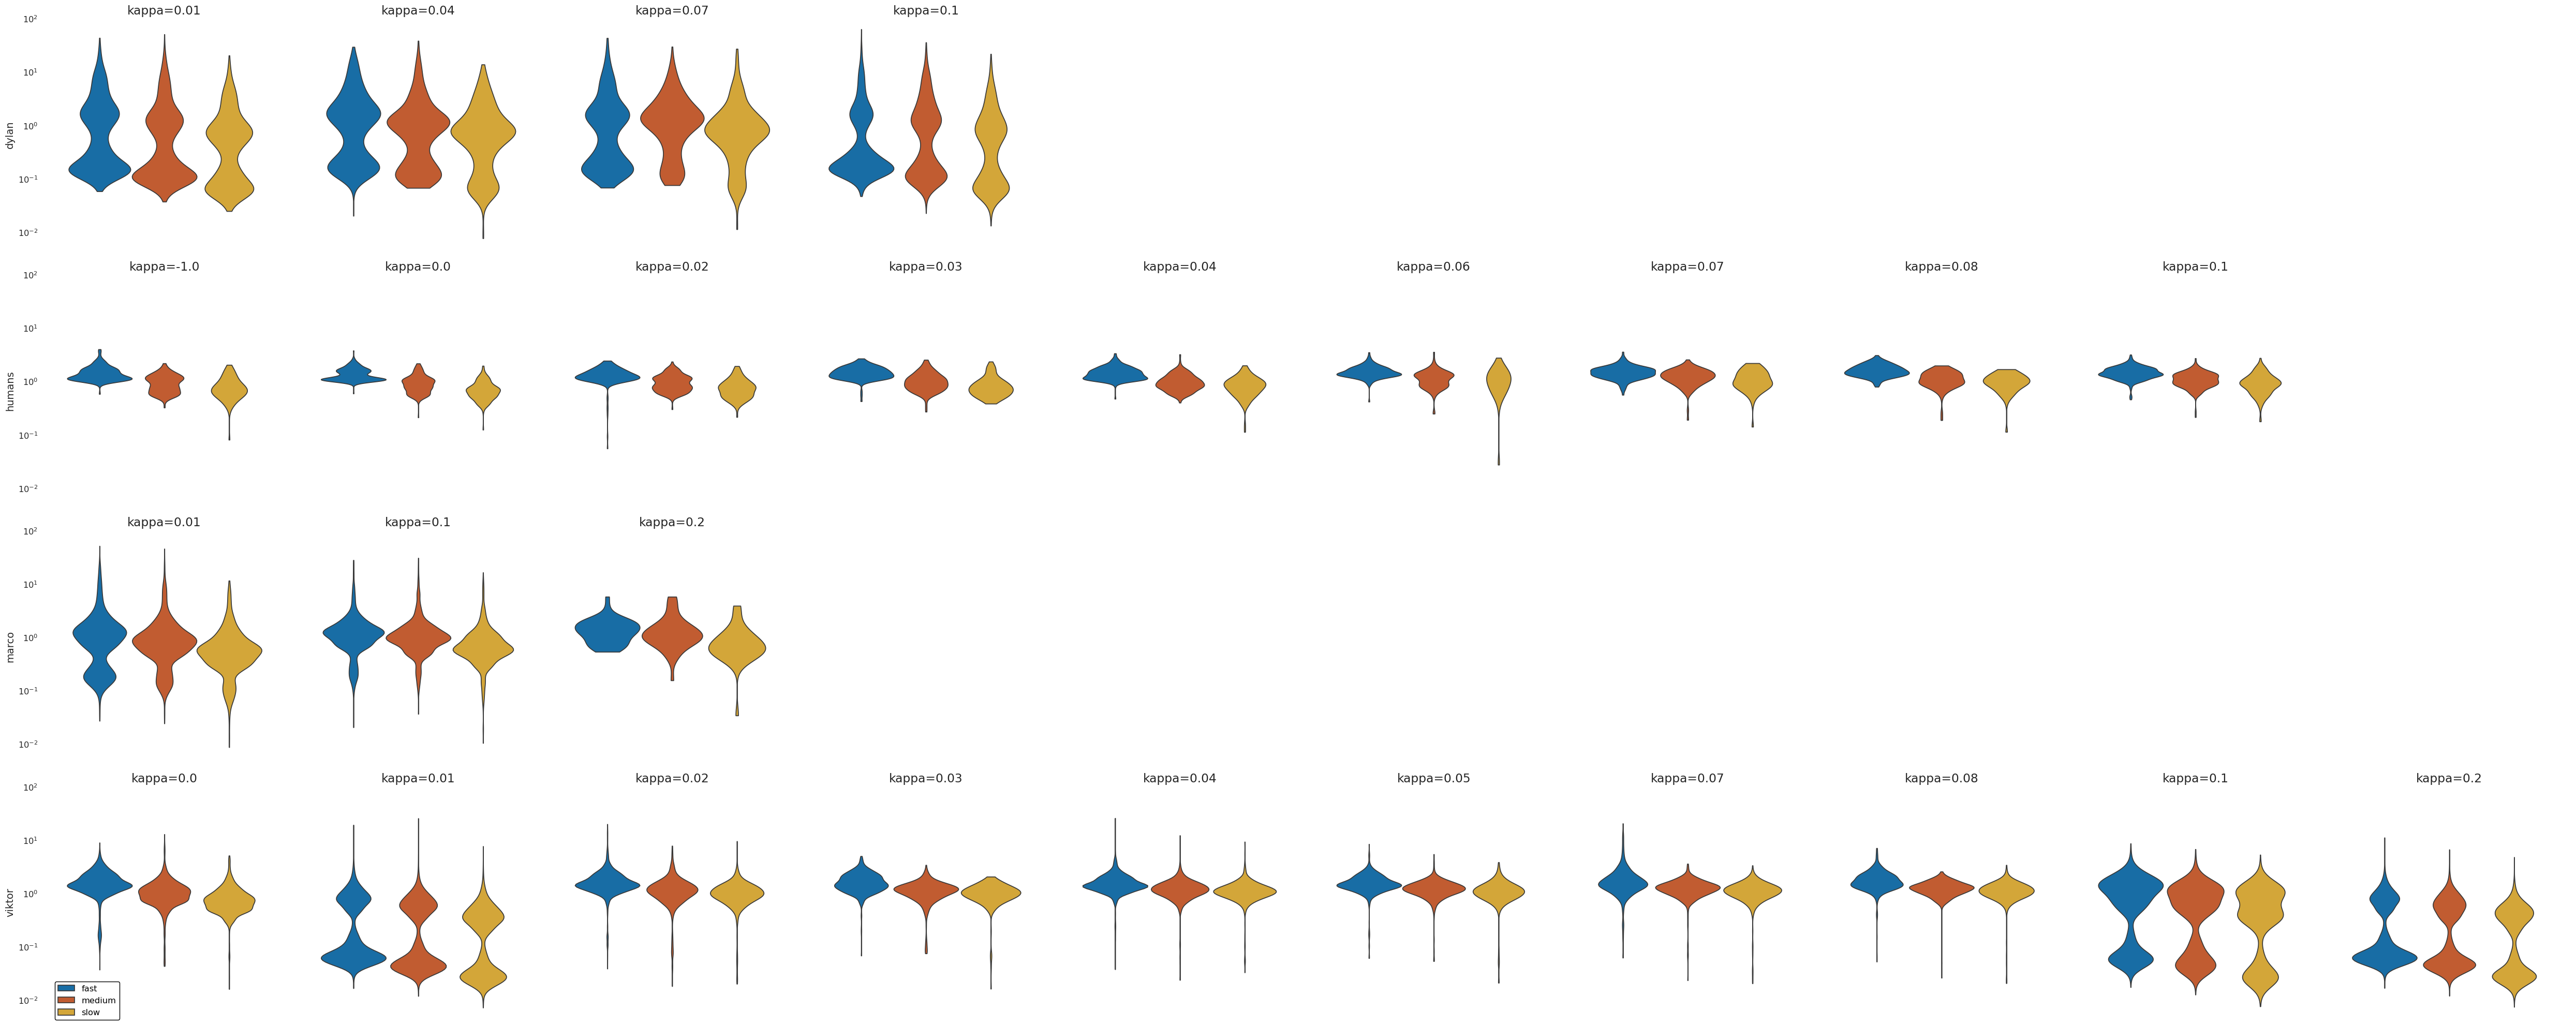

In [5]:
plotting.plot_variable_subplots(
    df,
    bp(sns.violinplot),
    "subject",
    "kappa",
    fig_kwargs={"sharey": True},
    y="normalized pushes",
    accumulate=True,
    cut=0,
    inner=None,
    common_norm=True,
    log_scale=True,
    legend=True,
)

# Push Intervals Over Time
Bin pushes over time.

array([[<Axes: title={'center': 'kappa=0.01'}, xlabel='time bins', ylabel='dylan'>,
        <Axes: title={'center': 'kappa=0.04'}, xlabel='time bins'>,
        <Axes: title={'center': 'kappa=0.07'}, xlabel='time bins'>,
        <Axes: title={'center': 'kappa=0.1'}, xlabel='time bins'>,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: title={'center': 'kappa=-1.0'}, xlabel='time bins', ylabel='humans'>,
        <Axes: title={'center': 'kappa=0.0'}, xlabel='time bins'>,
        <Axes: title={'center': 'kappa=0.02'}, xlabel='time bins'>,
        <Axes: title={'center': 'kappa=0.03'}, xlabel='time bins'>,
        <Axes: title={'center': 'kappa=0.04'}, xlabel='time bins'>,
        <Axes: title={'center': 'kappa=0.06'}, xlabel='time bins'>,
        <Axes: title={'center': 'kappa=0.07'}, xlabel='time bins'>,
        <Axes: title={'center': 'kappa=0.08'}, xlabel='time bins'>,
        <Axes: title={'center': 'kappa=0.1'}, xlabel='time bins'>,
        <Axes: >]

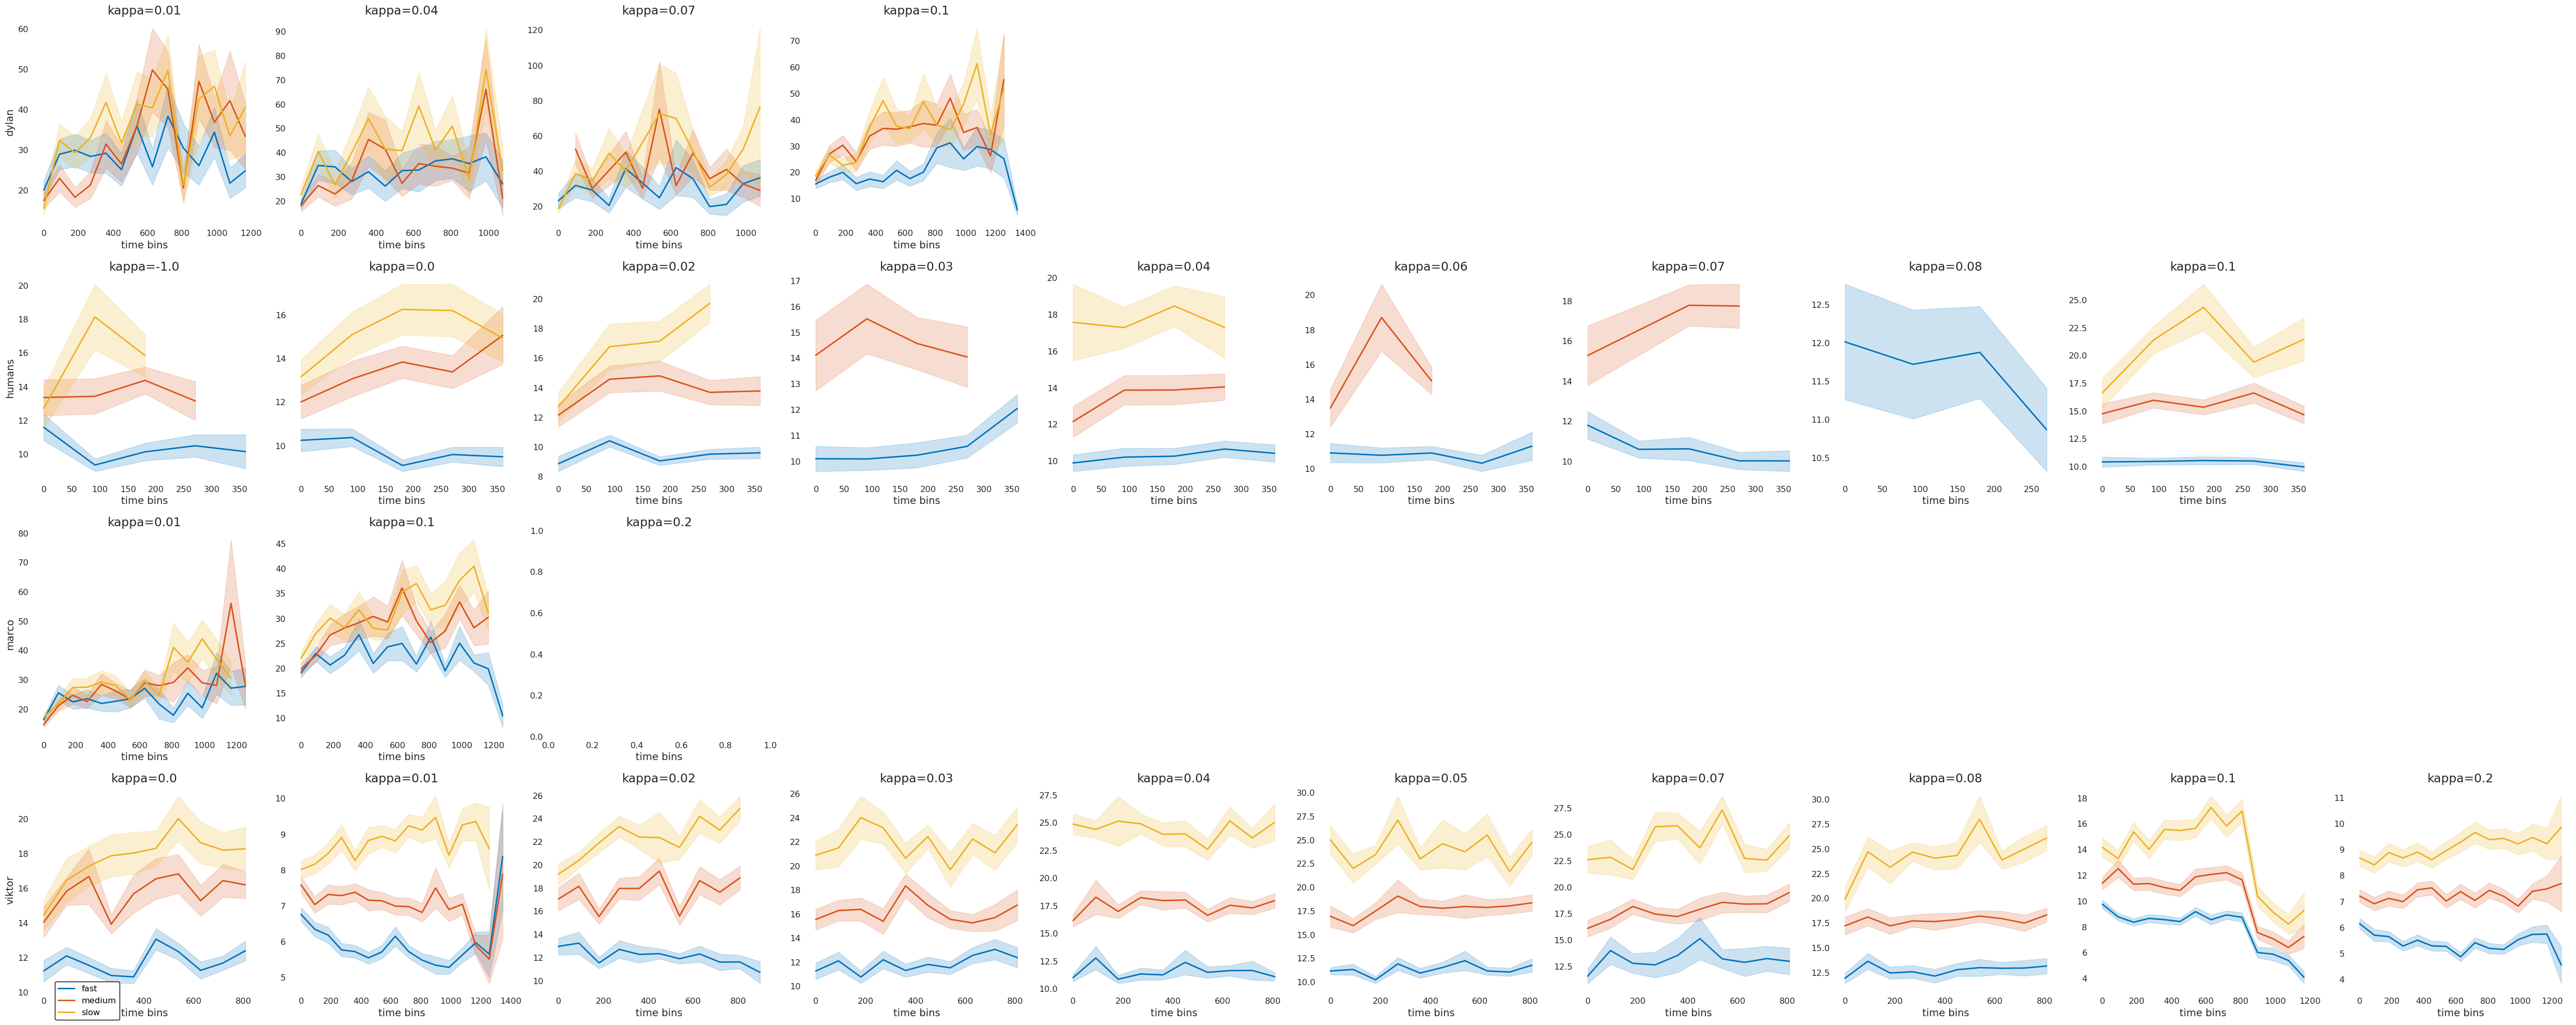

In [10]:
%%capture --no-display
# Bin data
x_bins = "time bins"
df[x_bins] = utils.data.bin_data(df, "push times", bins=20)
plotting.plot_variable_subplots(
    df,
    bp(sns.lineplot),
    "subject",
    "kappa",
    x=x_bins,
    y="same-box push intervals",
    accumulate=True,
    errorbar="se",
    legend=True,
    min_obs=20,
)

# Push Frequencies (Option 1)
A natural bin-less way is to take 1/push interval.

array([[<Axes: title={'center': 'kappa=0.01'}, xlabel='time bins', ylabel='dylan'>,
        <Axes: title={'center': 'kappa=0.04'}, xlabel='time bins'>,
        <Axes: title={'center': 'kappa=0.07'}, xlabel='time bins'>,
        <Axes: title={'center': 'kappa=0.1'}, xlabel='time bins'>,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: title={'center': 'kappa=-1.0'}, xlabel='time bins', ylabel='humans'>,
        <Axes: title={'center': 'kappa=0.0'}, xlabel='time bins'>,
        <Axes: title={'center': 'kappa=0.02'}, xlabel='time bins'>,
        <Axes: title={'center': 'kappa=0.03'}, xlabel='time bins'>,
        <Axes: title={'center': 'kappa=0.04'}, xlabel='time bins'>,
        <Axes: title={'center': 'kappa=0.06'}, xlabel='time bins'>,
        <Axes: title={'center': 'kappa=0.07'}, xlabel='time bins'>,
        <Axes: title={'center': 'kappa=0.08'}, xlabel='time bins'>,
        <Axes: title={'center': 'kappa=0.1'}, xlabel='time bins'>,
        <Axes: >]

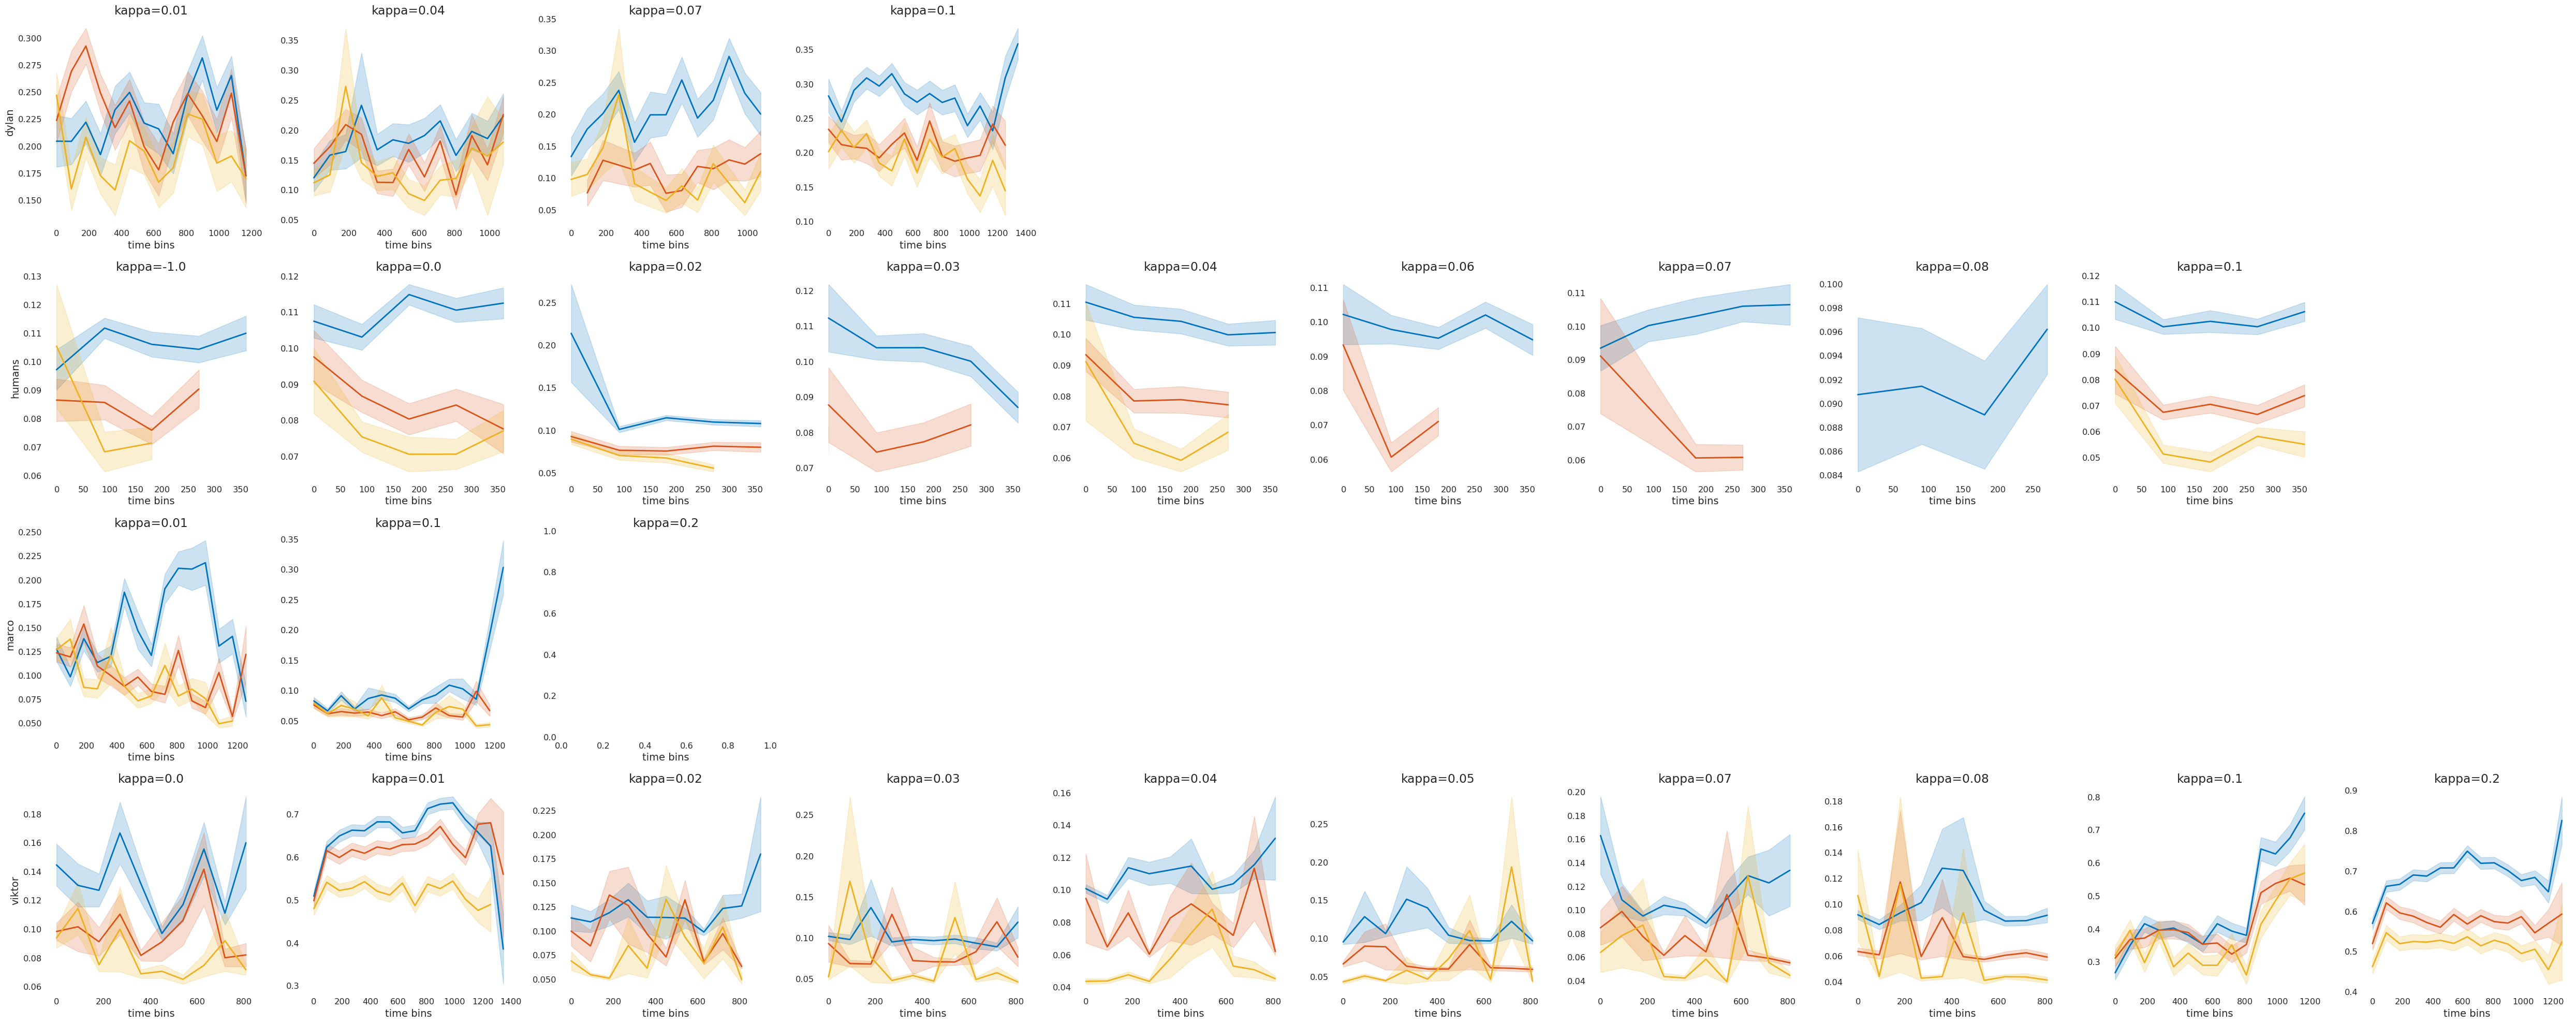

In [13]:
%%capture --no-display
# Invert push intervals
df["push frequencies"] = 1 / df["same-box push intervals"]
plotting.plot_variable_subplots(
    df,
    bp(sns.lineplot),
    "subject",
    "kappa",
    x=x_bins,
    y="push frequencies",
    accumulate=True,
    errorbar="se",
    legend=False,
    min_obs=20,
)

# Push Intervals vs Reward Intervals

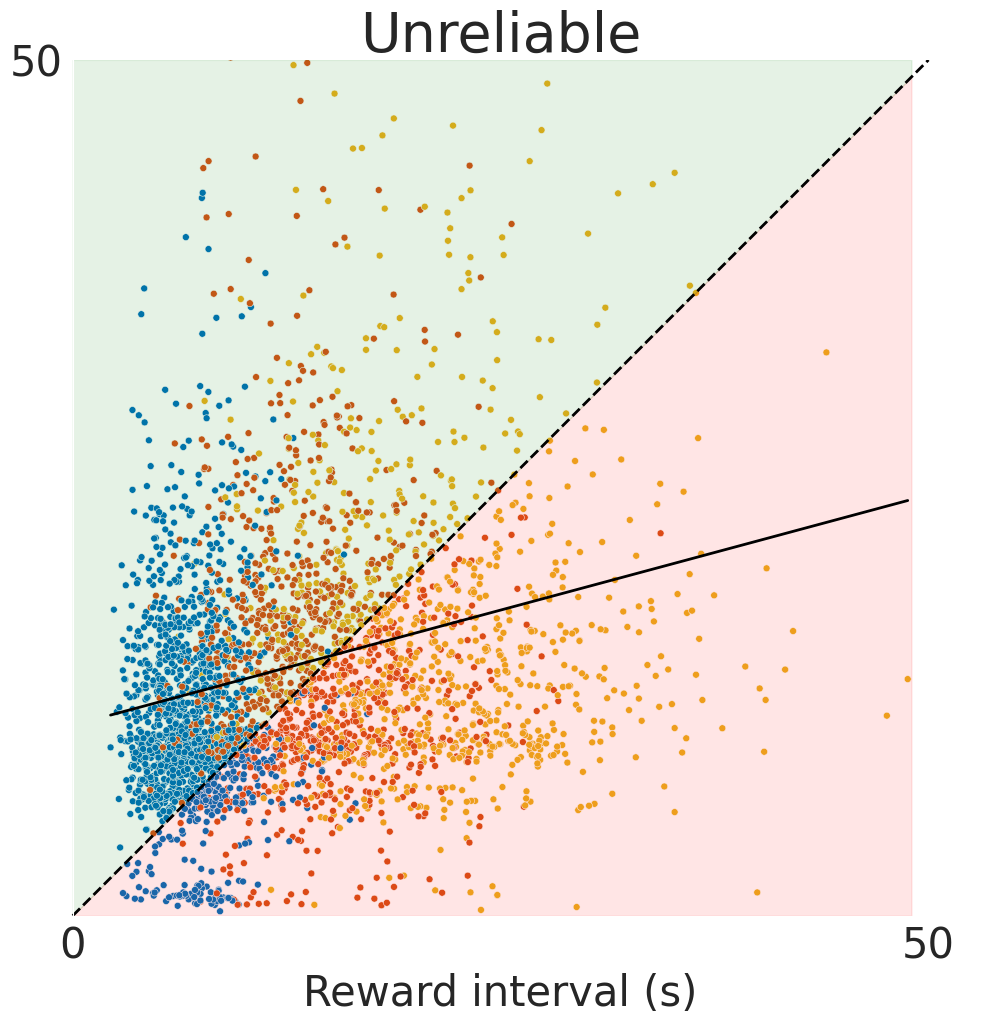

In [14]:
df_gamma = df.xs(("viktor", 10, 0.0), level=("subject", "shape", "kappa"))
ax = plotting.behavior.plot_push_intervals_vs_reward_intervals(
    df_gamma,
    accumulate=True,
    legend=False,
    legend_kwargs={
        "fontsize": 20,
        "markerscale": 3,
        "title_fontsize": 20,
        "title": "Box",
    },
)
ax[0].set_yticks([50], labels=[50], fontsize=30)
ax[0].set_ylim([0, 50])
ax[0].set_xticks([0, 50], labels=[0, 50], fontsize=30)
ax[0].tick_params(axis="x", labelsize=30)  # Change x-axis tick label size
ax[0].tick_params(axis="y", labelsize=30)
x = np.arange(50)
y = np.ones(50)
ax[0].fill_between(x, x, color="red", alpha=0.1)
ax[0].fill_between(x, x, 50, color="green", alpha=0.1)

ax[0].set_aspect("equal")
ax[0].set_ylabel("", fontsize=30)
ax[0].set_xlabel("Reward interval (s)", fontsize=30)
ax[0].set_title("Unreliable", fontsize=40)
ax[0].spines["left"].set_position("zero")  # Move the y-axis spine to x=0
ax[0].spines["bottom"].set_position("zero")  # Move the x-axis spine to y=0
ax[0].plot([0, 50], [0, 50], linestyle="dashed", color="black")

# Runlengths vs Reward Interval of Next Box
Promising idea, but no results :(

<Axes: xlabel="next box's reward interval", ylabel='length'>

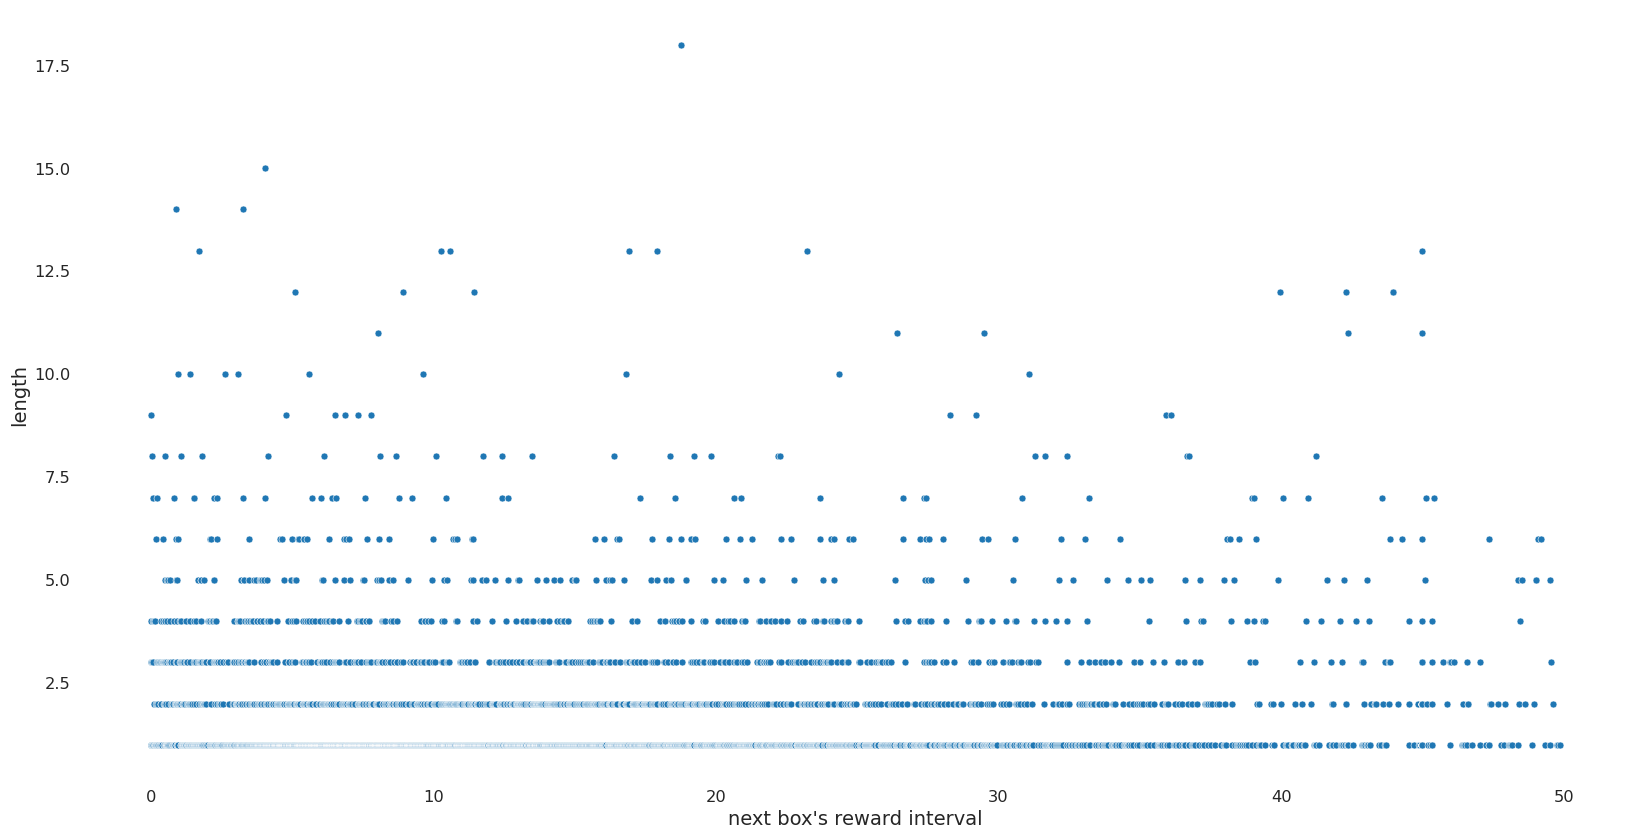

In [4]:
# Condition on reward interval of box that is switched to-- plot will have reward interval on x-axis and number of consecutive pushes at previous box on y-axis
# Identify consecutive pushes and when they switch
x = df.index.get_level_values("push #")
consecutive_mask = x[1:] - x[:-1] == 1
change_mask = (df["stay/switch"] == "switch") & np.insert(consecutive_mask, 0, True)
push_nums = (
    utils.data.get_blocks(df)["push times"].rank().astype(int)
)  # Calculate from scratch in case pushes got dropped
change_mask[push_nums == 1] = True

# Count the runlengths at different boxes
group_labels = change_mask.cumsum()
labeled_lengths = pd.DataFrame(
    {
        "group": group_labels,
        "box": df["box"],
        "next box's reward interval": utils.data.get_blocks(df["reward intervals"])
        .shift(-1)
        .fillna("missing"),
    }
).set_index(df.index)
labeled_lengths["next box's reward interval"] = labeled_lengths.groupby("group")[
    "next box's reward interval"
].transform("last")
labeled_lengths_all = (
    labeled_lengths.groupby(["subject", "kappa", "box", "group"])
    .size()
    .to_frame()
    .rename(columns={0: "length"})
)
# labeled_lengths_all = labeled_lengths_all[
#     (labeled_lengths_all['length'] > 1) & (labeled_lengths_all['length'] <= 10)]
labeled_lengths_all = labeled_lengths_all[(labeled_lengths_all["length"] > 1)]

# Calculate the distribution of runlengths under a dice that is rolled by visitation frequencies
visit_freqs = (
    df.groupby(["subject", "kappa"])["box"].value_counts(normalize=True).to_frame()
)

labeled_lengths_by_rew_interval = (
    labeled_lengths.groupby(
        ["subject", "kappa", "next box's reward interval", "box", "group"]
    )
    .size()
    .to_frame()
    .rename(columns={0: "length"})
    .reset_index(level="next box's reward interval")
)
labeled_lengths_by_rew_interval = labeled_lengths_by_rew_interval[
    labeled_lengths_by_rew_interval != "missing"
]
labeled_lengths_by_rew_interval = labeled_lengths_by_rew_interval[
    labeled_lengths_by_rew_interval["next box's reward interval"] <= 50
]
sns.scatterplot(
    labeled_lengths_by_rew_interval.loc[("viktor", 0.1)],
    x="next box's reward interval",
    y="length",
)

# Continuous Position

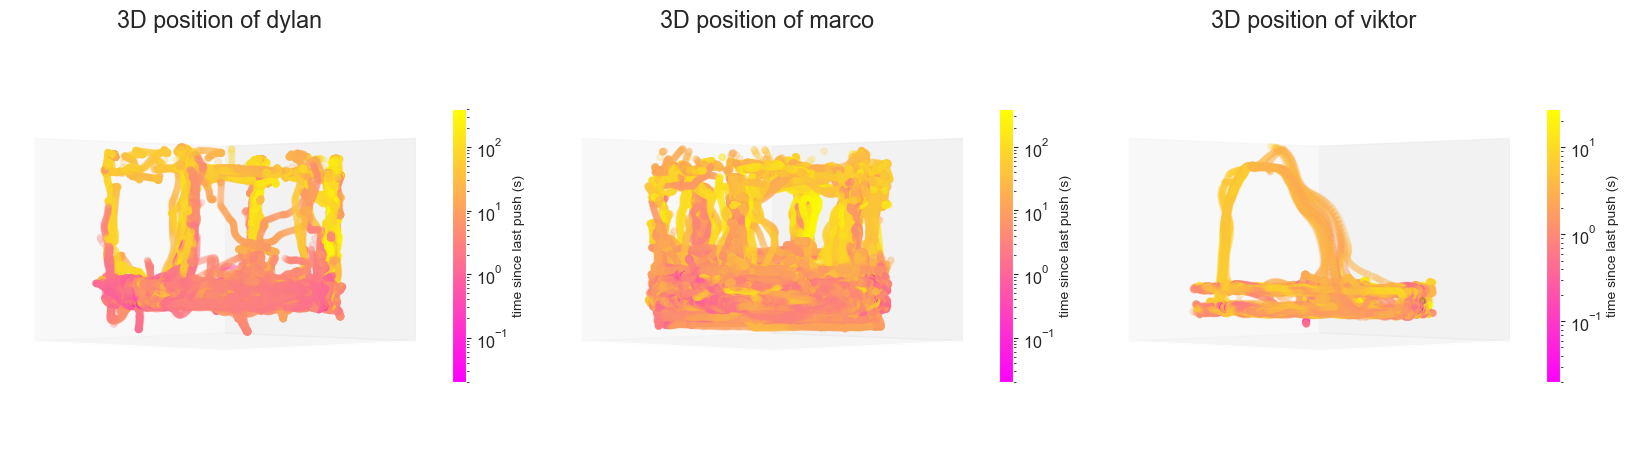

In [8]:
def filter_percentiles(df, p, n):
    subset = df.loc[(df["push percentiles"] >= p[0]) & (df["push percentiles"] <= p[1])]
    n = min(n, len(subset))  # Prevent errors if n > len(df)
    return subset.sample(n)


# Evenly sample pushes from each percentile bracket
df = utils.data.make_df(os.path.join(DATA_DIR, "experiments"))
df["push percentiles"] = df.groupby("subject", as_index=False)[
    "consecutive push intervals"
].rank(pct=True)
n_samples = 1000
percentiles_brackets = zip(
    np.arange(0, 1, 0.2), np.arange(0.2, 1.2, 0.2)
)  # [(0, 0.2)...(0.8, 1)]
perc_dfs = []
for p in percentiles_brackets:
    perc_dfs.append(
        df.groupby("subject", group_keys=False).apply(
            filter_percentiles, p=p, n=n_samples
        )
    )
all_perc_df = pd.concat(
    perc_dfs
)  # This creates a DataFrame that groups pushes by subject and percentile brackets
continuous_data, errors = get_continuous_from_df_to_dict(df, EXPERIMENT_DIR)

# Plot each push's 3d position data as a function of time since the start of the push
fig = plt.figure(figsize=(20, 10))
cbars = []
j = 0
subjects = df.index.unique("subject")
for i, subject in enumerate(subjects):
    if subject == "humans":
        continue
    df_subj = filter_df(all_perc_df, {"subject": subject}, attempt_index=False)
    ax = fig.add_subplot(1, len(subjects) - 1, j + 1, projection="3d")
    _, p = plot_continuous3d_df(
        df_subj,
        continuous_data,
        "position",
        title=f"3D position of {subject}",
        plt_kwargs={"alpha": 0.2, "cmap": "spring", "norm": LogNorm()},
        cbar_kwargs={"shrink": 0.7, "fraction": 0.03, "alpha": 1},
        ax=ax,
    )
    p.colorbar.set_label(p.colorbar.ax.get_ylabel(), fontsize=10)
    cbars.append(p.colorbar)
    j += 1

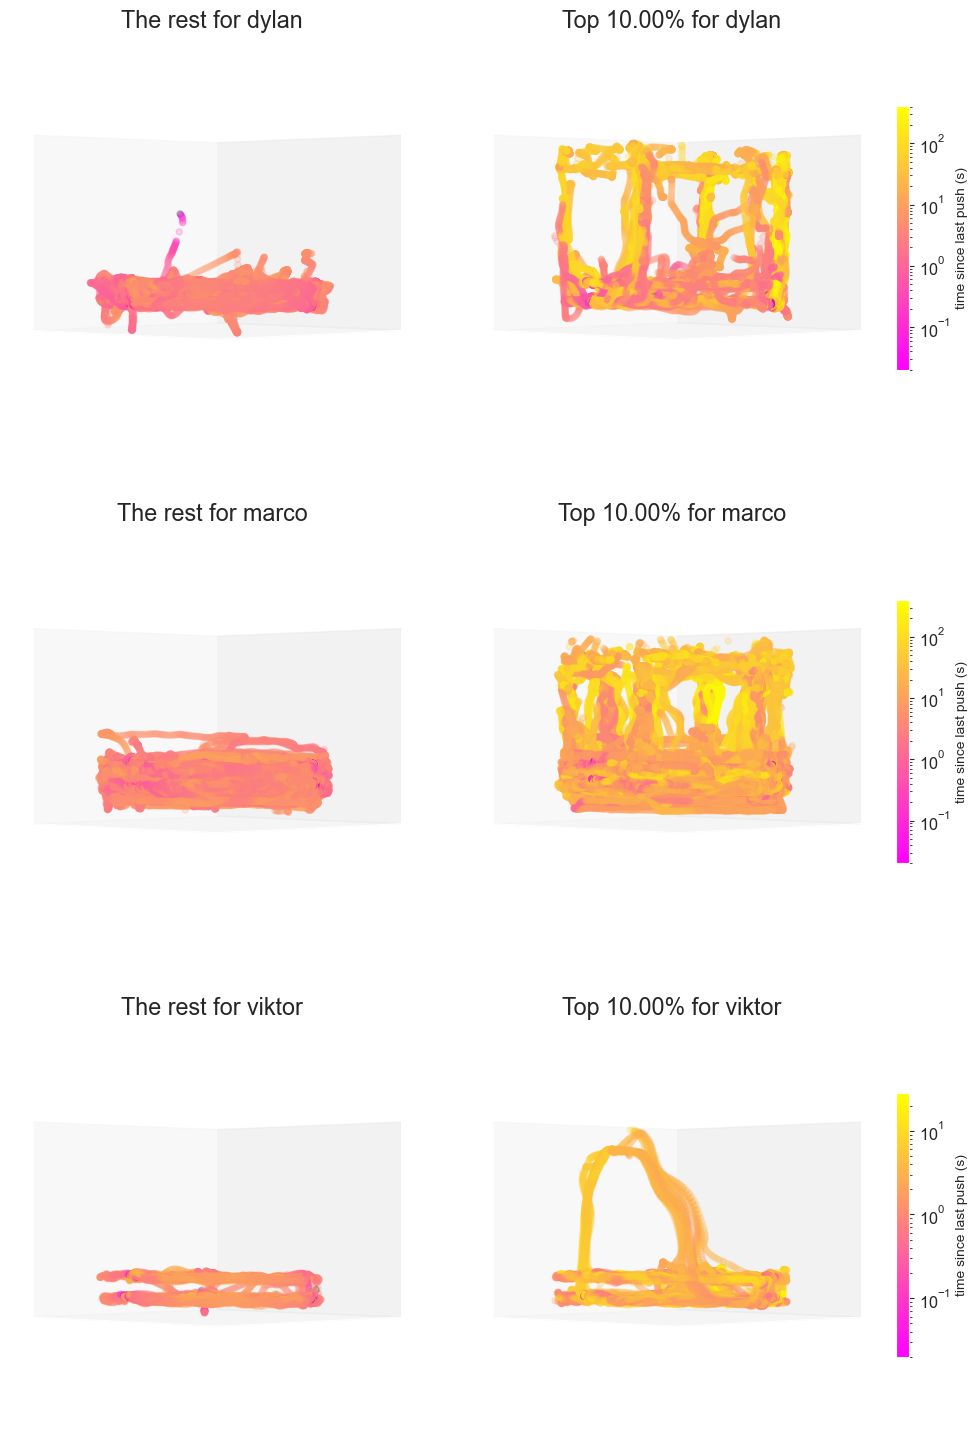

In [9]:
fig = plt.figure(figsize=(10, 20))
j = 0
for i, subject in enumerate(subjects):
    if subject == "humans":
        continue

    df_subj = filter_df(all_perc_df, {"subject": subject}, attempt_index=False)
    # perc = percentiles[subject]
    perc = 0.9

    # The rest
    ax = fig.add_subplot(len(subjects), 2, 2 * j + 1, projection="3d")
    ax1, p1 = plot_continuous3d_df(
        df_subj[df_subj["push percentiles"] < perc],
        continuous_data,
        "position",
        title=f"The rest for {subject}",
        plt_kwargs={"alpha": 0.2, "cmap": "spring", "norm": LogNorm()},
        cbar_kwargs={"shrink": 0.7, "fraction": 0.03, "alpha": 1},
        ax=ax,
    )
    c1 = p1.colorbar

    # Top x%
    ax = fig.add_subplot(
        len(subjects), 2, 2 * j + 2, projection="3d", sharex=ax, sharey=ax, sharez=ax
    )
    ax2, p2 = plot_continuous3d_df(
        df_subj[df_subj["push percentiles"] >= perc],
        continuous_data,
        "position",
        title=f"Top {(1 - perc) * 100:.2f}% for {subject}",
        plt_kwargs={"alpha": 0.2, "cmap": "spring", "norm": LogNorm()},
        cbar_kwargs={"shrink": 0.7, "fraction": 0.03, "alpha": 1},
        ax=ax,
    )
    c2 = p2.colorbar
    c2.set_label(c2.ax.get_ylabel(), fontsize=10)

    # Modify colors to be on the same scale post-hoc
    vmin = cbars[j].norm.vmin
    vmax = cbars[j].norm.vmax
    p1.set_clim(vmin, vmax)
    p2.set_clim(vmin, vmax)

    # Do this to preserve spatial layout
    c1.ax.set_visible(False)
    j += 1
fig.tight_layout()

ValueError: need at least one array to concatenate

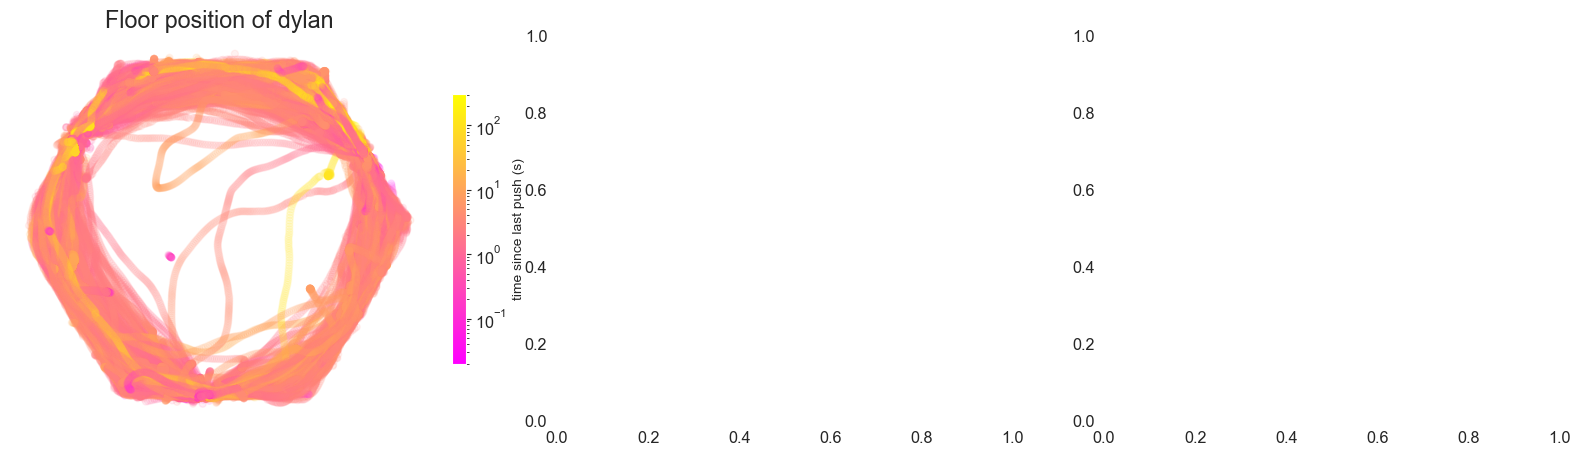

In [10]:
continuous_data_floor = {}
for k, v in continuous_data.items():
    idx = v["position"][:, 2] < 500
    continuous_data_floor[k] = {}
    for k1, v1 in v.items():
        if isinstance(v1, dict):
            continuous_data_floor[k][k1] = {k2: v2[idx] for k2, v2 in v1.items()}
        else:
            continuous_data_floor[k][k1] = v1[idx]

# Plot each push's 2d position data as a function of time since the start of the push
fig, ax = plt.subplots(1, 3, figsize=(20, 5))
for i, subject in enumerate(subjects):
    df_subj = filter_df(all_perc_df, {"subject": subject}, attempt_index=False)
    _, p = plot_continuous2d_df(
        df_subj,
        continuous_data_floor,
        "position",
        title=f"Floor position of {subject}",
        plt_kwargs={"alpha": 0.1, "cmap": "spring", "norm": LogNorm()},
        cbar_kwargs={"shrink": 0.7, "fraction": 0.03, "alpha": 1},
        ax=ax[i],
    )
    p.colorbar.set_label(p.colorbar.ax.get_ylabel(), fontsize=10)

In [ ]:
continuous_data_floor = {}
for k, v in continuous_data.items():
    idx = v["position"][:, 2] < 500
    continuous_data_floor[k] = {}
    for k1, v1 in v.items():
        if isinstance(v1, dict):
            continuous_data_floor[k][k1] = {k2: v2[idx] for k2, v2 in v1.items()}
        else:
            continuous_data_floor[k][k1] = v1[idx]

# Plot each push's 2d position data as a function of time since the start of the push
fig, ax = plt.subplots(1, 3, figsize=(20, 5))
for i, subject in enumerate(subjects):
    df_subj = filter_df(all_perc_df, {"subject": subject}, attempt_index=False)
    _, p = plot_continuous2d_df(
        df_subj,
        continuous_data_floor,
        "position",
        title=f"Floor position of {subject}",
        plt_kwargs={"alpha": 0.1, "cmap": "spring", "norm": LogNorm()},
        cbar_kwargs={"shrink": 0.7, "fraction": 0.03, "alpha": 1},
        ax=ax[i],
    )
    p.colorbar.set_label(p.colorbar.ax.get_ylabel(), fontsize=10)

# Visit Frequencies by Box Position

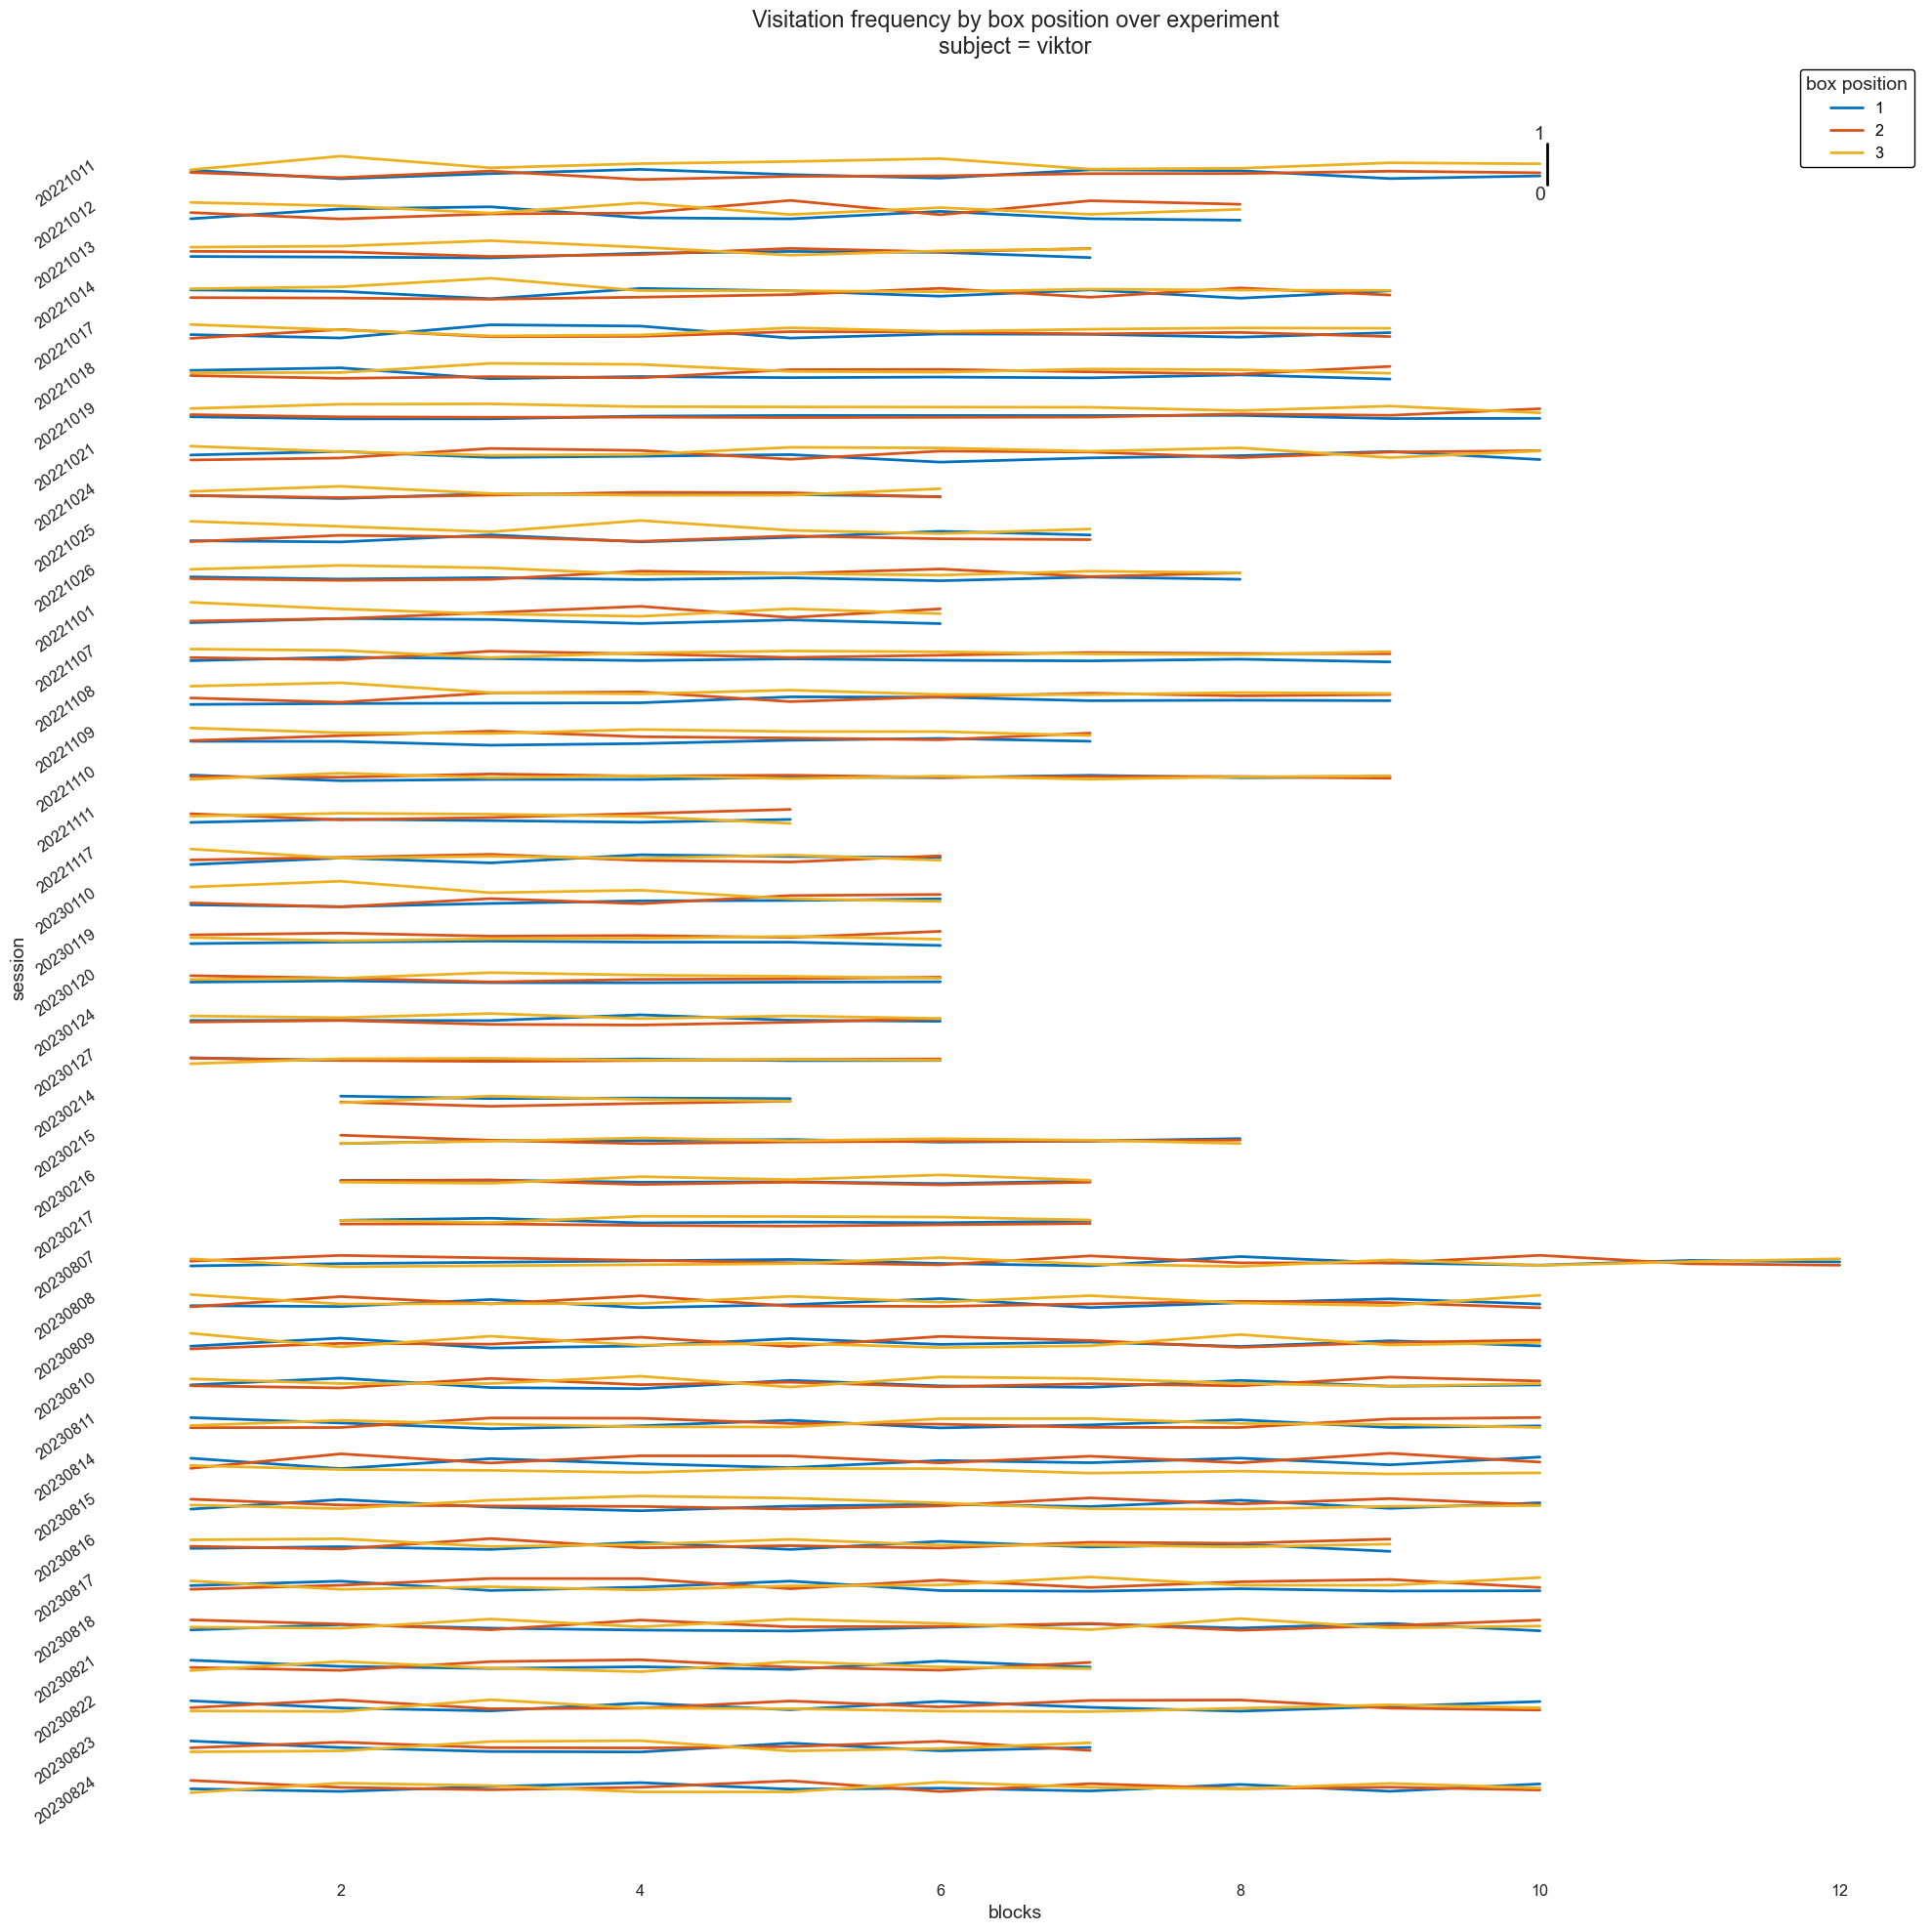

In [28]:
conds = dict(subject="viktor")
ax = plot_frequencies_over_experiment(
    df,
    "box position",
    conds=conds,
    title_prefix="Visitation frequency by box position over experiment",
    fig_kwargs=dict(figsize=(20, 20)),
)

# Spatial vs Quality Bias

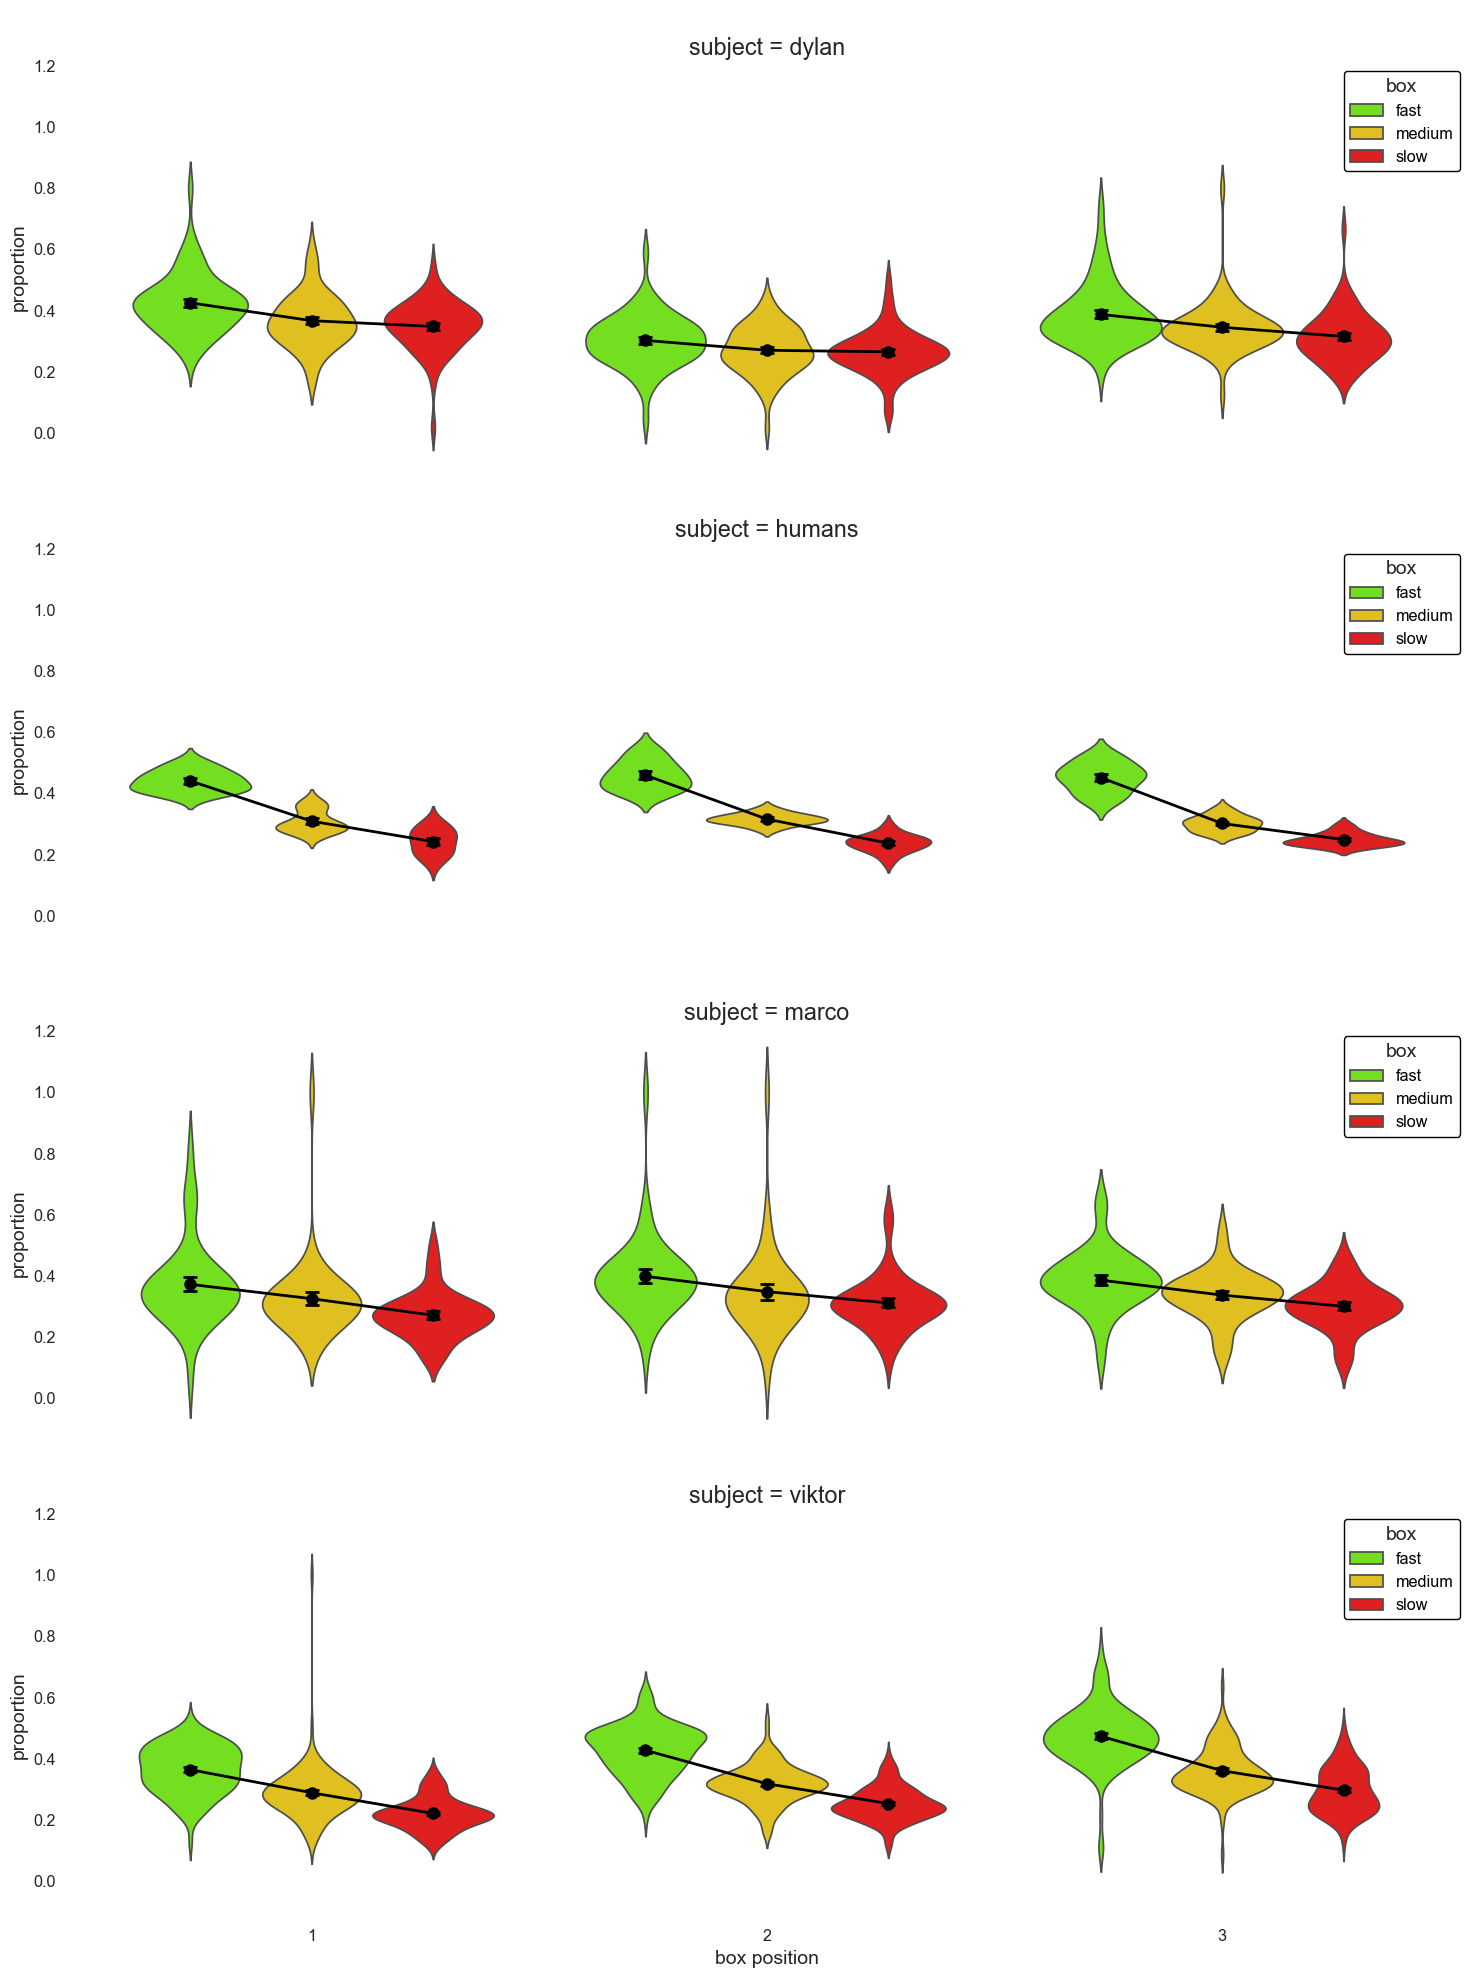

In [7]:
# Finally, rule out spatial bias vs box quality correlation in each block
visit_freqs_by_pos_quality = (
    get_blocks(df)[["box position", "box"]]
    .value_counts(normalize=True)
    .to_frame()
    .reset_index()
)
subjects = df.index.unique("subject")
fig, axes = plt.subplots(
    len(subjects), 1, figsize=(15, 5 * len(subjects)), sharex=True, sharey=True
)
for i, subj in enumerate(subjects):
    conds = dict(subject=subj)
    bp(enhanced_violinplot)(
        visit_freqs_by_pos_quality,
        conds=conds,
        x="box position",
        y="proportion",
        hue="box",
        inner=None,
        accumulate=True,
        ax=axes[i],
    )

# Fisher Information Across Blocks

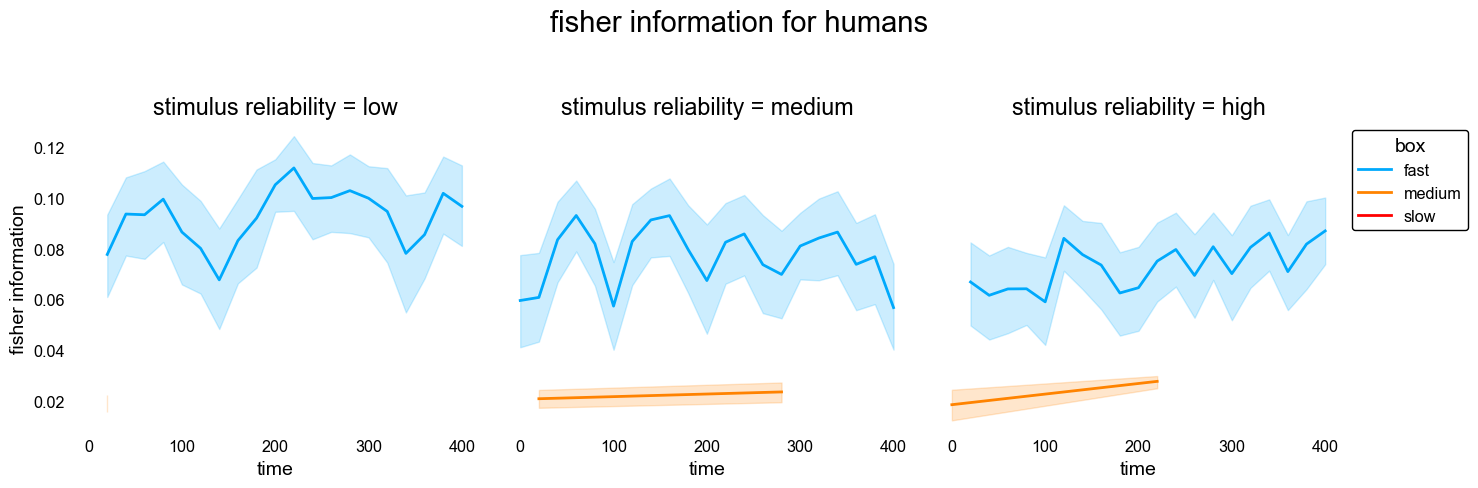

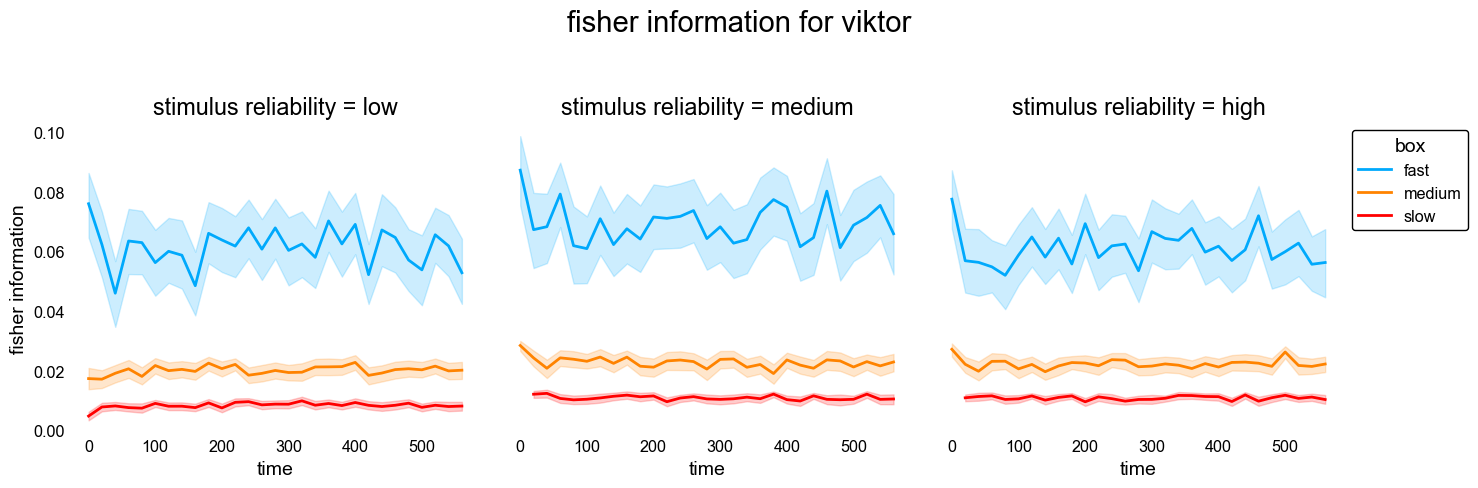

In [ ]:
%%capture --no-display
fisher_info, err_fisher = process_blocks(df, compute_fisher, use_tqdm=True)
extend_df(df, fisher_info, "fisher information")
plot_quantity_in_block(
    df,
    y="fisher information",
    legend_kwargs=dict(loc="upper left", bbox_to_anchor=(1, 1)),
    bin_kwargs=dict(bins=list(range(0, 60, 20)) + list(range(60, 600, 20))),
    min_obs=20,
)

As expected, the fisher information is ordered going fast box > medium box > slow box, so in theory the subjects should be able to figure out the schedule of the fast box the soonest. However, this may not be a fair comparison given the order of magnitude difference in maximum possible fisher information between the different boxes. Next, we can ask how informative is each push given the max information one can achieve by normalizing the fisher information by the max.

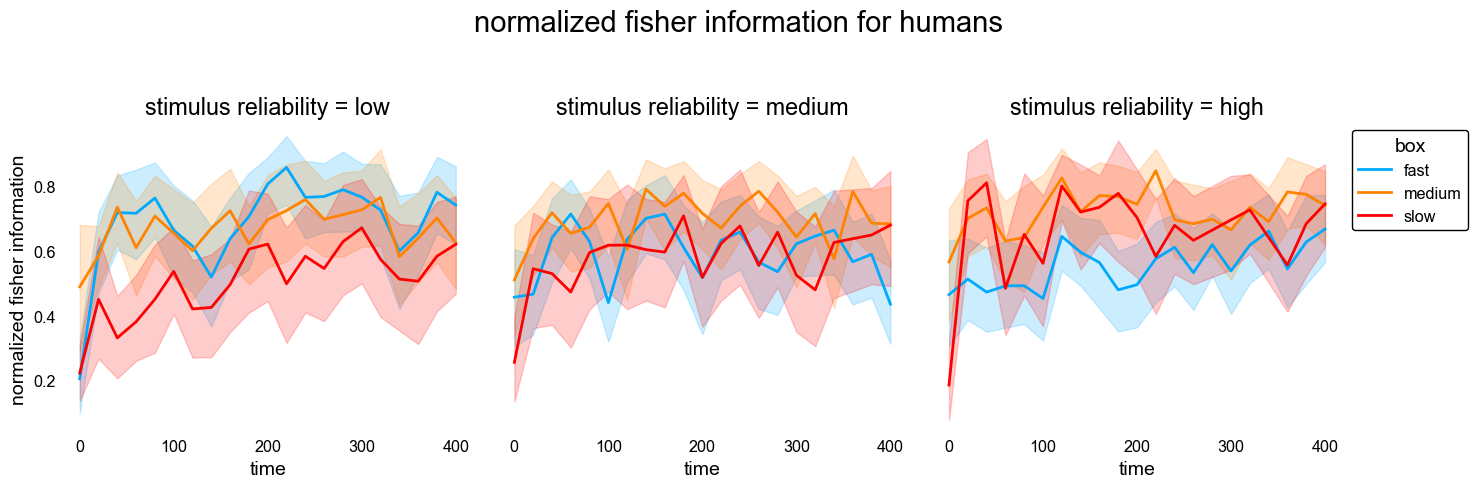

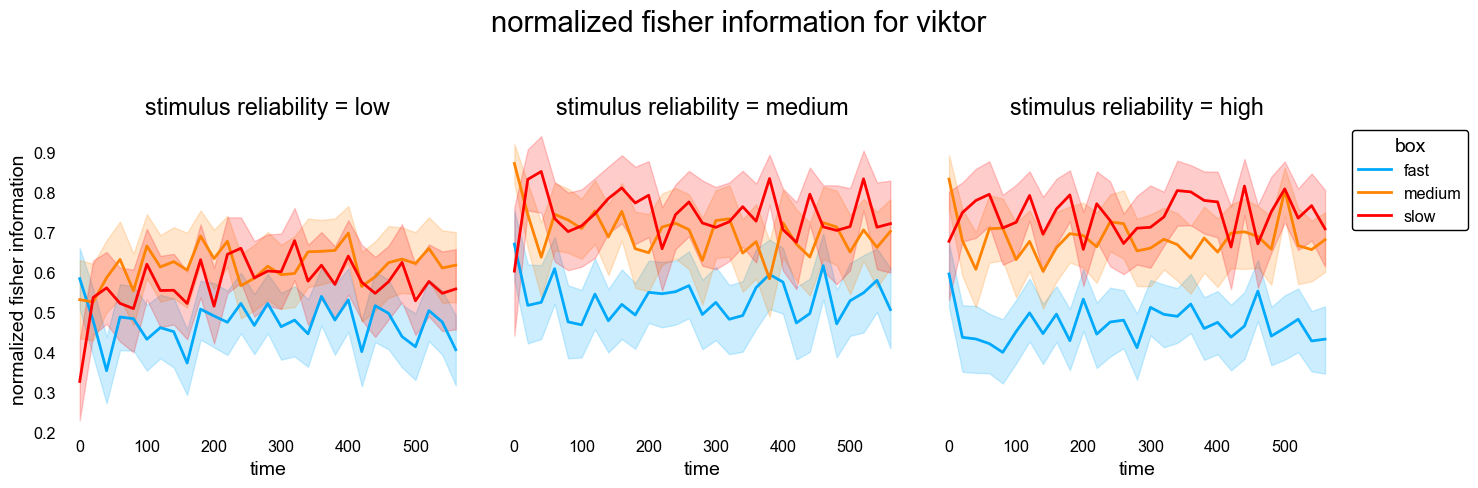

In [ ]:
%%capture --no-display
optimal_fisher_info = {7: 0.1303, 14: 0.0326, 21: 0.0145}
fisher_info_norm, err_fisher_norm = process_blocks(
    df, compute_normalized_fisher, use_tqdm=True, optimal_fisher=optimal_fisher_info
)
extend_df(df, fisher_info_norm, "normalized fisher information")
plot_quantity_in_block(
    df,
    y="normalized fisher information",
    legend_kwargs=dict(loc="upper left", bbox_to_anchor=(1, 1)),
    bin_kwargs=dict(bins=list(range(0, 60, 20)) + list(range(60, 600, 20))),
    min_obs=10,
)

It appears that even though the pushes at the fast box result in the highest raw fisher information, the other boxes tend to be near 100% of their fisher information. This isn't too surprising if the subjects have a strategy where they initially push within a range of 5-10s-- this way they can figure out the fast box first, then focus on other boxes while still getting a decent reward rate.

## Priors

<Axes: xlabel='chronological block', ylabel='wait times'>

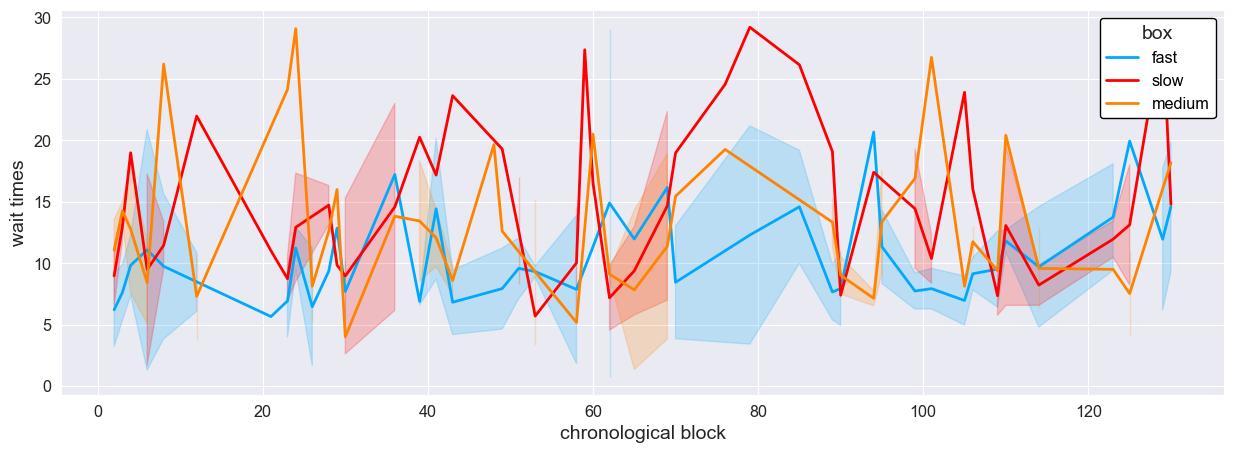

In [39]:
df["chronological block"] = (
    df.groupby(level=["subject", "session", "block"])
    .first()
    .sort_values(["subject", "session", "block"])
    .groupby("subject")
    .cumcount()
)
df_early = (
    df[(df["push times"] <= 30)].loc["viktor"].xs("low", level="stimulus reliability")
)
sns.lineplot(
    df_early,
    x="chronological block",
    y="wait times",
    hue="box",
    palette=PALETTE,
    errorbar="sd",
)

# Beliefs

 # Beliefs about schedule

Now that we have a sense of the theoretical upper bound on learning the schedules, we will look at the beliefs that a subject performing exact Bayesian inference may form over the actual censored observations $\{r_t\}$. We will consider the posteriors of each box to be pairwise independent and with uniform prior starting each block. The likelihood function is merely the cumulative density function $F$ of the gamma distribution if reward is delivered, and one minus this function otherwise. It is defined below for notational convenience:

$$L(r_t) = \begin{cases} F(t) & \text{for } r_t = 1 \\ 1-F(t) &  \text{for } r_t = 0 \end{cases}$$

Here is an example block's belief trajectories.

In [ ]:

plot_schedule_beliefs_mean_and_std_across_blocks(
    df, schedule_beliefs, x="n pushes", min_obs=20
)

In [ ]:

beliefs = schedule_beliefs
x = "push times"


# Get beliefs of each block
def _inner(df: pd.DataFrame, index: tuple):
    df_block = df.loc[index]
    posteriors = np.array(beliefs[index].features)
    schedule_candidates = beliefs[index].support[0]

    # Get mean and std of beliefs
    mean = get_mean_beliefs(posteriors, schedule_candidates)
    std = get_std_beliefs(posteriors, schedule_candidates)
    x_vals = df_block[x].values
    box = df_block["box"].values
    box_rank = df_block["box rank"].values
    res = {
        (index + (i,)): [
            mean[i + 1, box_rank[i]],
            std[i + 1, box_rank[i]],
            x_vals[i],
            box[i],
            i,
        ]
        for i in range(len(mean) - 1)
    }

    # Add prior
    for i in df_block["box rank"].unique():
        res[(index + (-i,))] = [mean[0, i], std[0, i], 0, box[0], 0]
    return res


res, _ = process_blocks(df, _inner)
res = reduce(lambda x, y: {**x, **y}, list(res.values()), {})
df_beliefs = pd.DataFrame.from_dict(
    res,
    orient="index",
    columns=["mean of belief", "s.d. of belief", x, "box", "n pushes"],
)

In [ ]:

# df_beliefs.index = pd.MultiIndex.from_tuples(df_beliefs.index, names = INDEX[:MIN_INDEX])
# df_beliefs.sort_index(inplace=True)
bp(sns.lineplot)(
    df_beliefs,
    x="push times",
    y="mean of belief",
    hue="box",
    palette=PALETTE,
    min_obs=20,
)

In [ ]:
bp(sns.lineplot)(
    df_beliefs,
    x="push times",
    y="s.d. of belief",
    hue="box",
    palette=PALETTE,
    min_obs=20,
)

In [ ]:
df_beliefs

In [ ]:
def mean(df: pd.DataFrame, index: tuple, exclude_prior: bool = True):

    # Get block data
    df_block = filter_df(df, conds)
    n_boxes = df_block["n boxes"].values[0]
    push_times = df_block["push times"].values
    posteriors = np.array(beliefs[tuple(conds.values())].features)
    schedule_candidates = beliefs[tuple(conds.values())].support[0]
    schedules = np.sort(df_block["schedule"].unique())
    mean_across_pushes = get_mean_beliefs(posteriors, schedule_candidates)[1:]

    res = utils.beliefs.get_mean_beliefs(
        posteriors[index].probabilities(record="all"), posteriors[index].support()
    )
    if exclude_prior:
        return [x[1:] for x in res]
    return res


def std(df: pd.DataFrame, index: tuple, exclude_prior: bool = True):
    res = utils.beliefs.get_std_beliefs(
        posteriors[index].probabilities(record="all"), posteriors[index].support()
    )
    if exclude_prior:
        return [x[1:] for x in res]
    return res


supp = np.arange(1, 30)
posteriors, err_beliefs = utils.data.process_blocks(
    df, utils.beliefs.compute_posteriors, supp, use_tqdm=True
)

mean_schedule, err_mean = utils.data.process_blocks(df, mean)
uncertainty_schedule, err_uncertainty = utils.data.process_blocks(df, std)
utils.data.extend_df(df, mean_schedule, "mean schedule", by_box=True)
utils.data.extend_df(df, uncertainty_schedule, "uncertainty schedule", by_box=True)

Here are the beliefs from an example block. Feel free to change the `index` values to change the block to display. You can also change `x_col` parameter to `push times` or even `push # by box` which shows the beliefs as a function of experience at each box.

In [ ]:
conds = dict(subject="viktor", session=20230811, block=3)
plotting.beliefs.schedule_beliefs_block(
    df, tuple(conds.values()), x="push times", fig_kwargs={"figsize": (30, 10)}
)

In [ ]:
plotting.behavior.plot_block_events(
    df, index, fig_kwargs={"figsize": (30, 2.2)}, legend=False
)

Aggregating across blocks, these are the means and uncertainties for Viktor, aligned by experience at each box.

In [ ]:
conds = {"subject": "viktor"}
df_monkey = utils.data.filter_df(df, conds=conds, attempt_index=False)

# Binning data with pd.cut
bin_edges = [0, 5, 10, 15, 20] + list(range(30, 120, 10))
df_monkey["push # bins"] = utils.data.bin_data(df_monkey, "push # by box", bin_edges)
ax = bp(sns.lineplot)(
    df_monkey,
    conds=conds,
    x="push # bins",
    y="mean schedule",
    accumulate=True,
    title_prefix="Mean belief as function of experience in block",
    min_obs=20,
)

In [ ]:
ax = bp(sns.lineplot)(
    df_monkey,
    conds=conds,
    x="push # bins",
    y="mean schedule",
    accumulate=True,
    title_prefix="Mean belief as function of experience in block",
    min_obs=20,
)

In [ ]:
bp(sns.lineplot)(
    df_monkey,
    conds=conds,
    x="push # bins",
    y="uncertainty schedule",
    accumulate=True,
    title_prefix="Uncertainty as function of experience in block",
    min_obs=20,
)

In [ ]:
df_ = df_monkey.xs(("viktor", 10), level=("subject", "shape")).reset_index()
subset_data = df_[df_["kappa"].isin([0, 0.1])]
sns.lineplot(subset_data, x="push # bins", y="uncertainty schedule", hue="kappa")

## Likelihood

In [ ]:
pts = np.linspace(0.2, 40)
LL = np.zeros((len(schedule_candidates) * len(pts), 3))
shape = 10
obs_model = utils.models.GammaObservation(shape)
c = np.zeros(LL.shape[0])
cnt = 0
for i, latent in enumerate(schedule_candidates):
    for j, pt in enumerate(pts):
        LL[cnt] = (latent, pt, obs_model.probability((1, pt), latent))
        c[cnt] = pt
        cnt += 1
fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(1, 1, 1, projection="3d")
ax.scatter(LL[:, 0], LL[:, 1], LL[:, 2], c=c)
ax.set_xlabel("schedule")
ax.set_ylabel("push interval")
ax.set_title("Likelihood of possible schedules \nafter observing reward")
# df_monkey['same-box push intervals'].min(), df_monkey['schedule'].max()

# Reward beliefs

In [ ]:
def rew_belief(df: pd.DataFrame, index: tuple, box):
    res = reward_beliefs[index][:, box, 1].squeeze()
    return res


def rew_prob(df: pd.DataFrame, index: tuple, box):
    res = reward_probabilities[index][:, box].squeeze()
    return res


rew_beliefs_blocks = [
    utils.data.process_blocks(df_monkey, rew_belief, box) for box in range(3)
]
rew_probs_blocks = [
    utils.data.process_blocks(df_monkey, rew_prob, box) for box in range(3)
]
[
    utils.data.extend_df(
        df_monkey, rew_beliefs_blocks[box][0], f"reward beliefs box={box}", by_box=False
    )
    for box in range(3)
]
[
    utils.data.extend_df(
        df_monkey, rew_probs_blocks[box][0], f"reward probs box={box}", by_box=False
    )
    for box in range(3)
]

In [ ]:
subject = "viktor"
plotting.beliefs.reward_beliefs3d(
    df_monkey,
    df_monkey[[f"reward beliefs box={x}" for x in range(3)]].values,
    title=f"Belief about reward availability \nat time of push for {subject}",
)

In [ ]:
plotting.beliefs.reward_beliefs3d(
    df_monkey,
    df_monkey[[f"reward probs box={x}" for x in range(3)]].values,
    title=f"Exact reward probability \nat time of push for {subject}",
)

## Predict pushed box

In [ ]:
# marginal beliefs
marginal_score, marginal_rsq, marginal_score_pval, marginal_rsq_pval, marginal_mdl = (
    utils.beliefs.predict_pushed_box(
        df_monkey, [f"reward beliefs box={x}" for x in range(3)], perm_test=True
    )
)

# perfect beliefs
perfect_score, perfect_rsq, perfect_score_pval, perfect_rsq_pval, perfect_mdl = (
    utils.beliefs.predict_pushed_box(
        df_monkey, [f"reward probs box={x}" for x in range(3)], perm_test=True
    )
)
print(
    f"marginal belief results: \n\t(accuracy, p-value) = ({marginal_score}, {marginal_score_pval})\n\t(r-squared, p-value) = ({marginal_rsq},{marginal_rsq_pval})"
)
print(
    f"perfect model results: \n\t(accuracy, p-value) = ({perfect_score}, {perfect_score_pval})\n\t(r-squared, p-value) = ({perfect_rsq},{perfect_rsq_pval})"
)

In [ ]:
min_obs = 20  # threshold for min obs for bin to be considered
belief_models = df_monkey.groupby("push # bins").apply(
    lambda g: (
        utils.beliefs.predict_pushed_box(
            g,
            [f"reward beliefs box={x}" for x in range(3)],
            perm_test=True,
            weight=True,
        )
        if len(g) >= min_obs
        else None
    )
)
perfect_models = df_monkey.groupby("push # bins").apply(
    lambda g: (
        utils.beliefs.predict_pushed_box(
            g, [f"reward probs box={x}" for x in range(3)], perm_test=True, weight=True
        )
        if len(g) >= min_obs
        else None
    )
)

# Accessing results for each group
beliefs_results = {}
for group, result in belief_models.items():
    print(f"\nGroup: {group}")
    if result is None:
        print("skipped!")
        continue
    print("result", result)
    beliefs_results[group] = result

In [ ]:
perfect_results = {}
for group, result in perfect_models.items():
    print(f"\nGroup: {group}")
    if result is None:
        print("skipped!")
        continue
    print("result", result)
    perfect_results[group] = result

In [ ]:
fig = plt.figure()
beliefs_arr = np.array([x[:-1] for x in beliefs_results.values()])
perfect_arr = np.array([x[:-1] for x in perfect_results.values()])
plt.plot(beliefs_results.keys(), beliefs_arr[:, 0], label="bayesian model", c="b")
plt.plot(perfect_results.keys(), perfect_arr[:, 0], label="perfect model", c="r")

# Denote significant points
sig_idx = beliefs_arr[:, 2] < 0.05
plt.scatter(
    np.array(list(beliefs_results.keys()))[sig_idx],
    beliefs_arr[sig_idx, 0],
    c="b",
    s=50,
)
sig_idx = perfect_arr[:, 2] < 0.05
plt.scatter(
    np.array(list(perfect_results.keys()))[sig_idx],
    perfect_arr[sig_idx, 0],
    c="r",
    s=50,
)

sig_idx = beliefs_arr[:, 2] > 0.05
plt.scatter(
    np.array(list(beliefs_results.keys()))[sig_idx],
    beliefs_arr[sig_idx, 0],
    c="b",
    s=50,
    marker="x",
)
sig_idx = perfect_arr[:, 2] > 0.05
plt.scatter(
    np.array(list(perfect_results.keys()))[sig_idx],
    perfect_arr[sig_idx, 0],
    c="r",
    s=50,
    marker="x",
)

plt.xlabel("push # by box")
plt.ylabel("% boxes correctly predicted")
plt.legend()

In [ ]:
fig = plt.figure()
beliefs_arr = np.array([x[:-1] for x in beliefs_results.values()])
perfect_arr = np.array([x[:-1] for x in perfect_results.values()])
plt.plot(beliefs_results.keys(), beliefs_arr[:, 1], label="bayesian model", c="b")
plt.plot(perfect_results.keys(), perfect_arr[:, 1], label="perfect model", c="r")

# Denote significant points
sig_idx = beliefs_arr[:, 3] < 0.05
plt.scatter(
    np.array(list(beliefs_results.keys()))[sig_idx],
    beliefs_arr[sig_idx, 1],
    c="b",
    s=50,
)
sig_idx = perfect_arr[:, 3] < 0.05
plt.scatter(
    np.array(list(perfect_results.keys()))[sig_idx],
    perfect_arr[sig_idx, 1],
    c="r",
    s=50,
)

sig_idx = beliefs_arr[:, 3] > 0.05
plt.scatter(
    np.array(list(beliefs_results.keys()))[sig_idx],
    beliefs_arr[sig_idx, 1],
    c="b",
    s=50,
    marker="x",
)
sig_idx = perfect_arr[:, 3] > 0.05
plt.scatter(
    np.array(list(perfect_results.keys()))[sig_idx],
    perfect_arr[sig_idx, 1],
    c="r",
    s=50,
    marker="x",
)

plt.xlabel("push # by box")
plt.ylabel("pseudo r-squared")
plt.legend()

## Likelihood under probabilistic policy with negligible action costs

In [ ]:
def exclude_column_indices(n_cols: int, exclude_indices: np.ndarray) -> np.ndarray:
    """
    Generate a matrix where each row contains all column indices except for the one given in exclude_indices.

    Args:
        n_cols (int): Total number of columns.
        exclude_indices (np.ndarray): Array of column indices to exclude per row.

    Returns:
        np.ndarray: Matrix where each row contains all column indices except the excluded one.
    """
    all_indices = np.arange(n_cols)  # Create an array of all column indices
    return np.array([np.delete(all_indices, i) for i in exclude_indices])


def belief_likelihood_push(df: pd.DataFrame, index: tuple):
    df_block = df.loc[index]
    data = reward_beliefs[index]
    picked_probs = data[
        np.arange(data.shape[0])[:, None], df_block["box rank"].values[:, None], 1
    ].squeeze()
    not_picked_index = exclude_column_indices(3, df_block["box rank"].values)
    not_picked_probs = data[
        np.arange(data.shape[0])[:, None], not_picked_index, 1
    ].squeeze()
    # print(picked_probs.shape, not_picked_probs.shape, df_block['box rank'].values.shape, not_picked_index.shape)
    return picked_probs * (1 - not_picked_probs[:, 0]) * (1 - not_picked_probs[:, 1])


def rew_prob_likelihood_push(df: pd.DataFrame, index: tuple):
    df_block = df.loc[index]
    data = reward_probabilities[index]
    picked_probs = data[
        np.arange(data.shape[0])[:, None], df_block["box rank"].values[:, None]
    ].squeeze()
    not_picked_index = exclude_column_indices(3, df_block["box rank"].values)
    not_picked_probs = data[
        np.arange(data.shape[0])[:, None], not_picked_index
    ].squeeze()
    return picked_probs * (1 - not_picked_probs[:, 0]) * (1 - not_picked_probs[:, 1])


rew_beliefs_blocks, _ = utils.data.process_blocks(df_monkey, belief_likelihood_push)
rew_probs_blocks, _ = utils.data.process_blocks(df_monkey, rew_prob_likelihood_push)
utils.data.extend_df(df_monkey, rew_beliefs_blocks, f"likelihood beliefs", by_box=False)
utils.data.extend_df(
    df_monkey, rew_probs_blocks, f"likelihood reward probs", by_box=False
)

In [ ]:
fig, ax = plt.subplots()
sns.lineplot(
    data=df_monkey,
    x="push # bins",
    y="likelihood beliefs",
    ax=ax,
    label="bayesian model",
)
sns.lineplot(
    data=df_monkey,
    x="push # bins",
    y="likelihood reward probs",
    ax=ax,
    label="perfect model",
)
ax.legend()
ax.set_ylabel("probabilistic policy likelihood")

In [ ]:
df_monkey2 = utils.data.make_df(os.path.join(DATA_DIR, "experiments"))

In [ ]:

data_pairs = defaultdict(lambda: np.zeros((3, 3)))
old_index = None
for index, block in utils.data.get_blocks(df_monkey2):
    box = block.loc[index + (1,), "box"].iloc[0]
    if old_index is None:
        old_index = index
        continue
    else:
        if (
            old_index[0] == index[0]
            and old_index[1] == index[1]
            and old_index[2] + 1 == index[2]
        ):
            _df = df_monkey2.loc[old_index]
            try:
                box_rank = _df.loc[_df["box"] == box, "box rank"].iloc[0]
                data_pairs[index[0]][box - 1, box_rank] += 1
            except:
                pass
        old_index = index

In [ ]:
fig, ax = plt.subplots(4, 1, figsize=(10, 30))
for i, (subj, data) in enumerate(data_pairs.items()):
    sns.heatmap(data, annot=True, cmap="Blues", cbar=True, linewidths=0.5, ax=ax[i])
    # ax[i].imshow(data)
    ax[i].set_ylabel("physical box location of first push")
    ax[i].set_xlabel("speed of pushed box in previous block")
    ax[i].set_title(f"{subj}'s data")

# Thompson sampling

In [ ]:

supp = np.linspace(0, 1, 50)
a, b = ts_posterior[("viktor", 30, 5)].probabilities(record="all")[0][25]
c, d = ts_posterior[("viktor", 30, 5)].probabilities(record="all")[1][25]
e, f = ts_posterior[("viktor", 30, 5)].probabilities(record="all")[2][25]
probs = [
    scipy.stats.beta.pdf(supp, a, b),
    scipy.stats.beta.pdf(supp, c, d),
    scipy.stats.beta.pdf(supp, e, f),
]
print(a, b, c, d, e, f)
print(
    len(ts_posterior[("viktor", 30, 8)].probabilities(record="all")[0]),
    len(ts_posterior[("viktor", 30, 8)].probabilities(record="all")[1]),
    len(ts_posterior[("viktor", 30, 8)].probabilities(record="all")[2]),
)
plt.plot(supp, probs[0], color=BOX_COLORS[0], label=BOX_LABELS[0])
plt.plot(supp, probs[1], color=BOX_COLORS[1], label=BOX_LABELS[1])
plt.plot(supp, probs[2], color=BOX_COLORS[2], label=BOX_LABELS[2])
plt.legend()
plt.xlabel("Probability of reward")
plt.title("Beta-distributed beliefs about reward probability at beginning of block")

# Moving average messiness

Pandas rolling window on timeseries requires converting to datetime objects and doesn't even create sliding window data in the expected way. What's the point.

In [ ]:
def _calculate_time_based_moving_average(
    df: pd.DataFrame, 
    time_col: str, 
    value_col: str, 
    window_size: str = '1s', 
    window_type: str = "rolling", 
    min_periods: int = None, 
    center: bool = False
) -> pd.Series:
    """
    Calculate time-based moving average using pandas' native time-based rolling functionality.
    
    Args:
        df: DataFrame containing the data
        time_col: Column name containing timestamps
        value_col: Column name containing values to average
        window_size: Time window size as a pandas offset string (e.g., '30s', '1H', '5min')
        window_type: Type of moving average ('rolling', 'ewm', 'expanding')
        min_periods: Minimum number of observations in window required to have a value
        center: If True, center the window around the current point
        
    Returns:
        Series containing the moving average values
    """
    # Create a copy to avoid modifying the original DataFrame

    if window_type == "rolling":
        # Use pandas' native time-based rolling
        # Convert window_size to timedelta for time-based rolling
        if isinstance(window_size, str):
            window_timedelta = pd.Timedelta(window_size)
        else:
            window_timedelta = pd.Timedelta(seconds=window_size)
        
        rolling_obj = df[value_col].rolling(
            window=window_timedelta, 
            min_periods=min_periods, 
            center=center,
            on=time_col
        )
        return rolling_obj.mean()
    
    elif window_type == "ewm":
        # For exponential weighted moving average, use halflife parameter
        # Convert window_size to seconds for halflife parameter
        if isinstance(window_size, str):
            # Parse pandas offset string to get seconds
            if 's' in window_size:
                seconds = float(window_size.replace('s', ''))
            elif 'min' in window_size:
                seconds = float(window_size.replace('min', '')) * 60
            elif 'H' in window_size:
                seconds = float(window_size.replace('H', '')) * 3600
            else:
                raise ValueError(f"Unsupported time format: {window_size}")
        else:
            seconds = window_size
        
        # Use halflife parameter for time-based decay
        return df[value_col].ewm(halflife=seconds).mean()
    
    elif window_type == "expanding":
        # Expanding window doesn't need time specification
        return df[value_col].expanding(min_periods=min_periods).mean()
    
    else:
        raise ValueError(f"Unsupported window_type: {window_type}. Must be 'rolling', 'ewm', or 'expanding'")

def _calculate_observation_based_moving_average(
    df: pd.DataFrame, 
    value_col: str, 
    window_size: int, 
    window_type: str = "rolling", 
    min_periods: int = None, 
    center: bool = False
) -> pd.Series:
    """
    Calculate observation-based moving average using pandas' standard rolling functionality.
    
    Args:
        df: DataFrame containing the data
        value_col: Column name containing values to average
        window_size: Number of observations in the window
        window_type: Type of moving average ('rolling', 'ewm', 'expanding')
        min_periods: Minimum number of observations in window required to have a value
        center: If True, center the window around the current point
        
    Returns:
        Series containing the moving average values
    """
    if window_type == "rolling":
        if min_periods is None:
            min_periods = 1
        
        return df[value_col].rolling(
            window=window_size, 
            min_periods=min_periods, 
            center=center
        )
    
    elif window_type == "ewm":
        return df[value_col].ewm(span=window_size)
    
    elif window_type == "expanding":
        if min_periods is None:
            min_periods = 1
        return df[value_col].expanding(min_periods=min_periods)
    
    else:
        raise ValueError(f"Unsupported window_type: {window_type}. Must be 'rolling', 'ewm', or 'expanding'")

    
@legend_handler
def plot_moving_average(
    df: pd.DataFrame,
    time_col: str,
    value_col: str,
    window_size: str = "30s",
    window_type: str = "rolling",
    window_mode: str = "time",
    time_unit: str = "s",
    min_periods: int = None,
    center: bool = False,
    conds: dict = None,
    title: str = "Moving Average Time Series",
    x_label: str = None,
    y_label: str = None,
    ax: plt.Axes = None,
    **kwargs,
) -> plt.Axes:
    """
    Plot moving average of time series data with support for both time-based and observation-based windows.
    
    This function can handle unevenly spaced timestamps and provides two modes:
    - 'time': Uses a fixed time interval sliding window (e.g., 30 seconds)
    - 'observations': Uses a fixed number of observations sliding window
    
    Args:
        df: DataFrame containing the time series data
        time_col: Column name containing timestamps
        value_col: Column name containing values to average
        window_size: Size of the moving average window
                   - For 'time' mode: pandas offset string (e.g., '30s', '1H', '5min')
                   - For 'observations' mode: integer number of observations
        window_type: Type of moving average ('rolling', 'ewm', 'expanding')
        window_mode: Whether to use time-based ('time') or observation-based ('observations') windows
        min_periods: Minimum number of observations in window required to have a value
        center: If True, center the window around the current point
        conds: Dictionary to filter df
        title: Title of the plot
        x_label: Label for x-axis (defaults to time_col)
        y_label: Label for y-axis (defaults to value_col)
        ax: Axes to plot on. If None, a new figure and axes are created
        **kwargs: Additional keyword arguments passed to plt.plot
        
    Returns:
        The axes object
    """
    # Filter data if conditions provided
    if conds:
        df = filter_df(df, conds)
    
    # Sort by time column
    df_sorted = df.sort_values(time_col).reset_index(drop=True)
    
    # Calculate moving average based on window mode
    if window_mode == "time":
        moving_avg = _calculate_time_based_moving_average(
            df_sorted, time_col, value_col, window_size, window_type = window_type, time_unit = time_unit, min_periods = min_periods, center = center
        )
    else:
        # For observation-based, convert window_size to int if it's a string
        if isinstance(window_size, str):
            try:
                window_size = int(window_size)
            except ValueError:
                raise ValueError(f"window_size must be an integer for observation-based mode, got: {window_size}")
        
        moving_avg = _calculate_observation_based_moving_average(
            df_sorted, value_col, window_size, window_type, min_periods, center
        ).mean()
    
    # Create plot
    if ax is None:
        fig_kwargs = kwargs.pop("fig_kwargs", {})
        fig, ax = plt.subplots(**fig_kwargs)
    
    # Plot original data and moving average
    ax.plot(df_sorted[time_col], df_sorted[value_col], 
            alpha=0.5, label="Original Data", **kwargs)
    ax.plot(df_sorted[time_col], moving_avg, 
            linewidth=2, label=f"{window_type.title()} Moving Average", **kwargs)
    
    # Set labels and title
    if x_label is None:
        x_label = time_col
    if y_label is None:
        y_label = value_col
    
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    return ax
